#  TransReID entraîné sur VRAI — notebook Kaggle complet

**Objectif** : entraîner **TransReID** (He et al., ICCV 2021) sur le dataset
**VRAI** (Vehicle Re-identification in Aerial Imagery) et produire une
**évaluation réelle** complète :

| Livrable | Détail |
|---|---|
|  Modèle final | `transreid_vrai_final.pth` (checkpoint DeiT-Small + JPM) |
|  JSON d'évaluation | `rapport_evaluation_vrai.json` |
|  5 graphes PNG | courbes d'entraînement, CMC, ROC, latence, retrieval |
|  Zip final | `transreid_vrai_results.zip` (tout regroupé) |

**Protocole d'évaluation (local, vérité terrain RÉELLE)** :
Le pkl de test officiel ne contient pas la correspondance query→gallery
(elle était cachée côté serveur EvalAI : la chaîne aléatoire des noms de test
est unique par image). Le notebook construit donc un protocole rigoureux à
partir du train VRAI, dont les noms encodent la vraie identité (`ID_Cam_Frame`) :

* ~80 % des identités → **entraînement**
* ~20 % des identités (disjointes) → **évaluation** :
  * **Galerie (références)** = images caméra `0001`
  * **Requêtes (probes)** = images caméra `0002` (cross-camera)
* Métriques : 1:N (**Rank-1, Rank-5, Rank-10, mAP** + CMC), 1:1
  (**Accuracy, ROC/AUC**, multi-références), **latence** (hors calcul des
  embeddings de la galerie).


##  Avant de lancer (2 min)

1. **GPU** : Settings  → Accelerator → **GPU T4 x2** (ou T4) + **Internet ON** 
2. **Données** : vos données `vrai/` doivent être uploadées sur Kaggle —
   **en dossier directement** (glissez le dossier) **OU** en zip :
   ```bash
   cd /chemin/vers/data && zip -r vrai_data.zip vrai
   ```
   Puis :
   * kaggle.com → **Datasets → New Dataset → Upload** → glissez le dossier
     `vrai/` (ou `vrai_data.zip`) → **Create**
   * ici : **+ Add input** → cherchez le nom de votre dataset → l'attacher
   * le notebook accepte les deux formats automatiquement 
3. Exécuter toutes les cellules **dans l'ordre** (Run All).

>  Utilisez **un seul** notebook par session Kaggle : la variante 20 époques
> (test rapide) **ou** la variante 60 époques (résultat final) — ne les
> mélangez pas, sinon la reprise automatique reprendrait le checkpoint de
> l'autre variante.

> ⏱ Temps : entraînement ~2-3,5 h sur T4 (20 époques). Si la session
> expire, relancez simplement la **cellule d'entraînement** : elle reprend
> automatiquement au dernier checkpoint (aucune donnée perdue).


In [ ]:
# ============ VÉRIFICATION DE L'ENVIRONNEMENT ============
import torch

print('torch :', torch.__version__)
print('CUDA disponible :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))
    print('VRAM : {:.1f} Go'.format(torch.cuda.get_device_properties(0).total_memory / 1e9))
else:
    print('  Aucun GPU détecté — entraînement très lent (activez GPU T4 dans Settings).')


torch : 2.10.0+cu128
CUDA disponible : True
GPU : Tesla T4
VRAM : 15.6 Go


In [2]:
# ============ DÉPENDANCES (timm, yacs, opencv) ============
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'timm', 'yacs', 'opencv-python-headless'], check=True)
print('Dépendances OK.')


Dépendances OK.


In [3]:
# ============ 1) CLONER TRANSREID (code officiel) ============
import os, subprocess, base64, sys

TR = '/kaggle/working/TransReID'
if not os.path.isdir(TR):
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/damo-cv/TransReID.git', TR], check=True)
print('TransReID cloné dans', TR)

# ----- 2) Fichiers de support VRAI (embarqués) -----
FILES = {"datasets/vrai.py": "IyAtKi0gY29kaW5nOiB1dGYtOCAtKi0KIiIiClZSQUkgZGF0YXNldCBsb2FkZXIgZm9yIFRyYW5zUmVJRCAg4oCUICBwcm90b2NvbGUgZCfDqXZhbHVhdGlvbiBMT0NBTC4KClZSQUkgOiBWZWhpY2xlIFJlLWlkZW50aWZpY2F0aW9uIGluIEFlcmlhbCBJbWFnZXJ5IChXYW5nIGV0IGFsLiwgSUNDViAyMDE5KQpSZXBvIG9mZmljaWVsIDogaHR0cHM6Ly9naXRodWIuY29tL0ppYW9CTDEyMzQvVlJBSS1EYXRhc2V0CgpMYXlvdXQgYXR0ZW5kdSAoYXByw6hzIHVwbG9hZCBkdSB6aXAgc3VyIEthZ2dsZSkgOgogICAgPFJPT1RfRElSPi9WUkFJLwogICAg4pSc4pSA4pSAIGltYWdlc190cmFpbi8gICAgICAgICAgIyA2NiAxMTMgaW1hZ2VzIDogSURfQ2FtX0ZyYW1lLmpwZwogICAg4pSc4pSA4pSAIGltYWdlc19kZXYvICAgICAgICAgICAgIyA1OSA2MDggaW1hZ2VzIChmYWN1bHRhdGlmIHBvdXIgbCdlbnRyYcOubmVtZW50KQogICAg4pSc4pSA4pSAIHRyYWluX2Fubm90YXRpb24ucGtsCiAgICDilJzilIDilIAgdGVzdF9kZXZfYW5ub3RhdGlvbi5wa2wgICAoZmFjdWx0YXRpZikKICAgIOKUlOKUgOKUgCB0ZXN0X2Fubm90YXRpb24ucGtsICAgICAgIChmYWN1bHRhdGlmKQoKUHJvdG9jb2xlIGQnw6l2YWx1YXRpb24KLS0tLS0tLS0tLS0tLS0tLS0tLS0tLQpMZXMgcGtsIGRlIFRFU1QvZGV2IG5lIGNvbnRpZW5uZW50IFBBUyBsYSB2w6lyaXTDqSB0ZXJyYWluIGlkZW50aXTDqQpxdWVyeeKGkmdhbGxlcnkgOiBkYW5zIGxlIGNoYWxsZW5nZSBFdmFsQUksIGxhIGNoYcOubmUgYWzDqWF0b2lyZSBkdSBub20gZGUgdGVzdAplc3QgVU5JUVVFIFBBUiBJTUFHRSAoNTkgNjA4IHByw6lmaXhlcyB1bmlxdWVzIHBvdXIgNTkgNjA4IGltYWdlcywgYXVjdW4KY2hldmF1Y2hlbWVudCBxdWVyeS9nYWxsZXJ5KSBldCBsYSBjb3JyZXNwb25kYW5jZSDDqXRhaXQgY2FsY3Vsw6llIGPDtHTDqSBzZXJ2ZXVyCnBhciBsZXMgb3JnYW5pc2F0ZXVycy4gw4l2YWx1ZXIgbGUgcHJvdG9jb2xlIG9mZmljaWVsIGRldi90ZXN0IGxvY2FsZW1lbnQgZXN0CmRvbmMgaW1wb3NzaWJsZSBhdmVjIGxlcyBmaWNoaWVycyBwdWJsacOpcyAodm9pciByYW5kb21fZXZhbHVhdGlvbi5weSBkdSByZXBvCm9mZmljaWVsIDogaWwgbmUgZ8OpbsOocmUgcXVlIGRlcyBzdWJtaXNzaW9ucyBhbMOpYXRvaXJlcyBwb3VyIEV2YWxBSSkuCgpPbiBjb25zdHJ1aXQgZG9uYyB1biBwcm90b2NvbGUgZCfDqXZhbHVhdGlvbiBSSUdPVVJFVVggw6AgcGFydGlyIGR1IFRSQUlOLCBkb250CmxlcyBub21zIGVuY29kZW50IGxhIHZyYWllIGlkZW50aXTDqSAoSURfQ2FtX0ZyYW1lKSA6CiAgKiBzcGxpdCBkw6l0ZXJtaW5pc3RlIGRlcyBpZGVudGl0w6lzIDogfjIwICUgw6l2YWwgLyA4MCAlIHRyYWluCiAgICAgICAgKHVuZSBpZGVudGl0w6kgWCBlc3QgZW4gw6l2YWwgc2kgaW50KFgpICUgRVZBTF9NT0QgPT0gMCwgRVZBTF9NT0Q9NSA7CiAgICAgICAgIHZhcmlhYmxlIGQnZW52IFZSQUlfRVZBTF9NT0QgcG91ciBjaGFuZ2VyIGxhIHByb3BvcnRpb24pCiAgKiBHQUxFUklFIChyw6lmw6lyZW5jZXMpID0gdG91dGVzIGxlcyBpbWFnZXMgY2Ftw6lyYSAwMDAxIGRlcyBpZGVudGl0w6lzIMOpdmFsCiAgKiBRVUVSWSAocHJvYmUpICAgICAgICA9IHRvdXRlcyBsZXMgaW1hZ2VzIGNhbcOpcmEgMDAwMiBkZXMgbcOqbWVzIGlkZW50aXTDqXMKICDihpIgaWRlbnRpZmljYXRpb24gMTpOIChSYW5rLTEvNS8xMCwgbUFQKSBldCB2w6lyaWZpY2F0aW9uIDE6MSAoQWNjdXJhY3ksIFJPQykKICAgIGF2ZWMgdW5lIFZSQUlFIHbDqXJpdMOpIHRlcnJhaW4gaXNzdWUgZGVzIG5vbXMgZGUgZmljaGllcnMuCgpSw6l1dGlsaXNhYmxlIDogY29waWVyIGRhbnMgVHJhbnNSZUlEL2RhdGFzZXRzL3ZyYWkucHkgcHVpcyBsYW5jZXIKICAgIHB5dGhvbiBwYXRjaF9tYWtlX2RhdGFsb2FkZXIucHkgL2NoZW1pbi92ZXJzL1RyYW5zUmVJRAoiIiIKaW1wb3J0IGdsb2IKaW1wb3J0IG9zCmltcG9ydCBvcy5wYXRoIGFzIG9zcAppbXBvcnQgcGlja2xlCmltcG9ydCByZQoKZnJvbSAuYmFzZXMgaW1wb3J0IEJhc2VJbWFnZURhdGFzZXQKCl9fYWxsX18gPSBbJ1ZSQUknXQoKIyAxIGlkZW50aXTDqSBzdXIgRVZBTF9NT0QgZXN0IHLDqXNlcnbDqWUgw6AgbCfDqXZhbHVhdGlvbiAoZMOpdGVybWluaXN0ZSkKRVZBTF9NT0QgPSBpbnQob3MuZW52aXJvbi5nZXQoJ1ZSQUlfRVZBTF9NT0QnLCAnNScpKQoKCmNsYXNzIFZSQUkoQmFzZUltYWdlRGF0YXNldCk6CiAgICAiIiJWUkFJIOKAlCBWZWhpY2xlIFJlLWlkZW50aWZpY2F0aW9uIGluIEFlcmlhbCBJbWFnZXJ5LiIiIgoKICAgIGRhdGFzZXRfZGlyID0gJ1ZSQUknCgogICAgIyBOb21zIGRlIGRvc3NpZXJzIHBvc3NpYmxlcyAoYXV0by1kw6l0ZWN0aW9uLCBsJ29yZHJlIGNvbXB0ZSkKICAgIFRSQUlOX0RJUl9DQU5ESURBVEVTID0gWydpbWFnZXNfdHJhaW4nLCAnaW1hZ2VfdHJhaW4nLCAndHJhaW4nXQoKICAgIGRlZiBfX2luaXRfXyhzZWxmLCByb290PScnLCB2ZXJib3NlPVRydWUsICoqa3dhcmdzKToKICAgICAgICBzdXBlcihWUkFJLCBzZWxmKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5kYXRhc2V0X2RpciA9IG9zcC5qb2luKHJvb3QsIHNlbGYuZGF0YXNldF9kaXIpCiAgICAgICAgc2VsZi5fbG9jYXRlX2RpcnMoKQogICAgICAgIHNlbGYuX2xvY2F0ZV9wa2woKQogICAgICAgIHNlbGYuX2NoZWNrX2JlZm9yZV9ydW4oKQoKICAgICAgICB0cmFpbiwgcXVlcnksIGdhbGxlcnkgPSBzZWxmLl9wcm9jZXNzKCkKCiAgICAgICAgaWYgdmVyYm9zZToKICAgICAgICAgICAgcHJpbnQoJz0+IFZSQUkgbG9hZGVkJykKICAgICAgICAgICAgc2VsZi5wcmludF9kYXRhc2V0X3N0YXRpc3RpY3ModHJhaW4sIHF1ZXJ5LCBnYWxsZXJ5KQoKICAgICAgICBzZWxmLnRyYWluID0gdHJhaW4KICAgICAgICBzZWxmLnF1ZXJ5ID0gcXVlcnkKICAgICAgICBzZWxmLmdhbGxlcnkgPSBnYWxsZXJ5CgogICAgICAgIHNlbGYubnVtX3RyYWluX3BpZHMsIHNlbGYubnVtX3RyYWluX2ltZ3MsIHNlbGYubnVtX3RyYWluX2NhbXMsIHNlbGYubnVtX3RyYWluX3ZpZHMgPSBcCiAgICAgICAgICAgIHNlbGYuZ2V0X2ltYWdlZGF0YV9pbmZvKHNlbGYudHJhaW4pCiAgICAgICAgc2VsZi5udW1fcXVlcnlfcGlkcywgc2VsZi5udW1fcXVlcnlfaW1ncywgc2VsZi5udW1fcXVlcnlfY2Ftcywgc2VsZi5udW1fcXVlcnlfdmlkcyA9IFwKICAgICAgICAgICAgc2VsZi5nZXRfaW1hZ2VkYXRhX2luZm8oc2VsZi5xdWVyeSkKICAgICAgICBzZWxmLm51bV9nYWxsZXJ5X3BpZHMsIHNlbGYubnVtX2dhbGxlcnlfaW1ncywgc2VsZi5udW1fZ2FsbGVyeV9jYW1zLCBzZWxmLm51bV9nYWxsZXJ5X3ZpZHMgPSBcCiAgICAgICAgICAgIHNlbGYuZ2V0X2ltYWdlZGF0YV9pbmZvKHNlbGYuZ2FsbGVyeSkKCiAgICAgICAgIyBJTVBPUlRBTlQgOiBsZXMgdGFibGVzIFNJRSAoY2Ftw6lyYS92dWUpIGR1IG1vZMOobGUgZG9pdmVudCBjb3V2cmlyIFRPVVMKICAgICAgICAjIGxlcyBpbmRpY2VzIGRlIGNhbcOpcmEgb2JzZXJ2w6lzICh0cmFpbiArIHF1ZXJ5ICsgZ2FsbGVyeSkuCiAgICAgICAgYWxsX2NhbXMgPSB7Y2FtIGZvciBfLCBfLCBjYW0sIF8gaW4gKHNlbGYudHJhaW4gKyBzZWxmLnF1ZXJ5ICsgc2VsZi5nYWxsZXJ5KX0KICAgICAgICBzZWxmLm51bV90cmFpbl9jYW1zID0gbWF4KGFsbF9jYW1zKSArIDEgaWYgYWxsX2NhbXMgZWxzZSAyCiAgICAgICAgc2VsZi5udW1fdHJhaW5fdmlkcyA9IHNlbGYubnVtX3RyYWluX2NhbXMgICMgdmlld2lkID09IGNhbWlkIGRhbnMgY2UgbG9hZGVyCiAgICAgICAgc2VsZi5ldmFsX21vZCA9IEVWQUxfTU9ECgogICAgIyAtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0gIwogICAgIyAgTG9jYWxpc2F0aW9uIGRlcyBkb3NzaWVycyAvIHBrbCAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICMKICAgICMgLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tICMKICAgIGRlZiBfZmluZF9kaXIoc2VsZiwgY2FuZGlkYXRlcyk6CiAgICAgICAgZm9yIGMgaW4gY2FuZGlkYXRlczoKICAgICAgICAgICAgcCA9IG9zcC5qb2luKHNlbGYuZGF0YXNldF9kaXIsIGMpCiAgICAgICAgICAgIGlmIG9zcC5pc2RpcihwKToKICAgICAgICAgICAgICAgIHJldHVybiBwCiAgICAgICAgcmV0dXJuIE5vbmUKCiAgICBkZWYgX2xvY2F0ZV9kaXJzKHNlbGYpOgogICAgICAgIHNlbGYudHJhaW5fZGlyID0gc2VsZi5fZmluZF9kaXIoc2VsZi5UUkFJTl9ESVJfQ0FORElEQVRFUykKCiAgICBkZWYgX2xvY2F0ZV9wa2woc2VsZik6CiAgICAgICAgZGVmIF9maW5kKCpuYW1lcyk6CiAgICAgICAgICAgIGZvciBuIGluIG5hbWVzOgogICAgICAgICAgICAgICAgcCA9IG9zcC5qb2luKHNlbGYuZGF0YXNldF9kaXIsIG4pCiAgICAgICAgICAgICAgICBpZiBvc3AuaXNmaWxlKHApOgogICAgICAgICAgICAgICAgICAgIHJldHVybiBwCiAgICAgICAgICAgIHJldHVybiBOb25lCgogICAgICAgIHNlbGYudHJhaW5fcGtsID0gX2ZpbmQoJ3RyYWluX2Fubm90YXRpb24ucGtsJykKCiAgICBkZWYgX2NoZWNrX2JlZm9yZV9ydW4oc2VsZik6CiAgICAgICAgaWYgbm90IG9zcC5leGlzdHMoc2VsZi5kYXRhc2V0X2Rpcik6CiAgICAgICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcigiJ3t9JyBpcyBub3QgYXZhaWxhYmxlIi5mb3JtYXQoc2VsZi5kYXRhc2V0X2RpcikpCiAgICAgICAgaWYgc2VsZi50cmFpbl9kaXIgaXMgTm9uZToKICAgICAgICAgICAgcmFpc2UgUnVudGltZUVycm9yKAogICAgICAgICAgICAgICAgImRvc3NpZXIgZCdpbWFnZXMgdHJhaW4gaW50cm91dmFibGUgc291cyAne30nIChhdHRlbmR1IDogaW1hZ2VzX3RyYWluLykiLmZvcm1hdCgKICAgICAgICAgICAgICAgICAgICBzZWxmLmRhdGFzZXRfZGlyKSkKICAgICAgICBpZiBzZWxmLnRyYWluX3BrbCBpcyBOb25lOgogICAgICAgICAgICByYWlzZSBSdW50aW1lRXJyb3IoCiAgICAgICAgICAgICAgICAidHJhaW5fYW5ub3RhdGlvbi5wa2wgaW50cm91dmFibGUgc291cyAne30nIOKAlCByZXF1aXMgcG91ciBjb25zdHJ1aXJlICIKICAgICAgICAgICAgICAgICJsZSB0cmFpbiBldCBsZSBzcGxpdCBkJ8OpdmFsdWF0aW9uLiIuZm9ybWF0KHNlbGYuZGF0YXNldF9kaXIpKQoKICAgICMgLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tICMKICAgICMgIFV0aWxpdGFpcmVzICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAjCiAgICAjIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSAjCiAgICBAc3RhdGljbWV0aG9kCiAgICBkZWYgX2ltZ19maWxlcyhkaXJlY3RvcnkpOgogICAgICAgIGZpbGVzID0gW10KICAgICAgICBmb3IgZXh0IGluICgnKi5qcGcnLCAnKi5qcGVnJywgJyoucG5nJywgJyouSlBHJyk6CiAgICAgICAgICAgIGZpbGVzICs9IGdsb2IuZ2xvYihvc3Auam9pbihkaXJlY3RvcnksIGV4dCkpCiAgICAgICAgcmV0dXJuIGZpbGVzCgogICAgQHN0YXRpY21ldGhvZAogICAgZGVmIF9sb2FkX3BrbChwYXRoKToKICAgICAgICAiIiJDaGFyZ2UgdW4gcGlja2xlIFB5dGhvbiAyIG91IDMgZGUgbWFuacOocmUgcm9idXN0ZS4iIiIKICAgICAgICBpZiBwYXRoIGlzIE5vbmUgb3Igbm90IG9zcC5pc2ZpbGUocGF0aCk6CiAgICAgICAgICAgIHJldHVybiBOb25lCiAgICAgICAgdHJ5OgogICAgICAgICAgICB3aXRoIG9wZW4ocGF0aCwgJ3JiJykgYXMgZjoKICAgICAgICAgICAgICAgIHJldHVybiBwaWNrbGUubG9hZChmLCBlbmNvZGluZz0nbGF0aW4xJykKICAgICAgICBleGNlcHQgRXhjZXB0aW9uIGFzIGUxOgogICAgICAgICAgICB0cnk6CiAgICAgICAgICAgICAgICB3aXRoIG9wZW4ocGF0aCwgJ3JiJykgYXMgZjI6CiAgICAgICAgICAgICAgICAgICAgcmV0dXJuIHBpY2tsZS5sb2FkKGYyLCBlbmNvZGluZz0nYnl0ZXMnKQogICAgICAgICAgICBleGNlcHQgRXhjZXB0aW9uIGFzIGUyOgogICAgICAgICAgICAgICAgcHJpbnQoJ1tWUkFJXSB3YXJuaW5nOiB1bmFibGUgdG8gbG9hZCB7fSAoe30sIHt9KScuZm9ybWF0KHBhdGgsIGUxLCBlMikpCiAgICAgICAgICAgICAgICByZXR1cm4gTm9uZQoKICAgIEBzdGF0aWNtZXRob2QKICAgIGRlZiBfbm9ybV9uYW1lcyhsc3QpOgogICAgICAgICIiIkTDqWNvZGUgbGVzIG5vbXMgcydpbHMgc29udCBlbiBieXRlcyAocGlja2xlIFB5dGhvbiAyKS4iIiIKICAgICAgICBvdXQgPSBbXQogICAgICAgIGZvciBuIGluIGxzdDoKICAgICAgICAgICAgaWYgaXNpbnN0YW5jZShuLCBieXRlcyk6CiAgICAgICAgICAgICAgICBuID0gbi5kZWNvZGUoJ3V0Zi04JywgZXJyb3JzPSdyZXBsYWNlJykKICAgICAgICAgICAgb3V0LmFwcGVuZChzdHIobikpCiAgICAgICAgcmV0dXJuIG91dAoKICAgICMgLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tICMKICAgICMgIENvbnN0cnVjdGlvbiB0cmFpbiAvIHF1ZXJ5IC8gZ2FsbGVyeSAodsOpcml0w6kgdGVycmFpbiByw6llbGxlKSAgICAgICAgIwogICAgIyAtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0gIwogICAgZGVmIF9wcm9jZXNzKHNlbGYpOgogICAgICAgIHRyYWluX3BrbCA9IHNlbGYuX2xvYWRfcGtsKHNlbGYudHJhaW5fcGtsKQogICAgICAgIGltX25hbWVzID0gc2VsZi5fbm9ybV9uYW1lcyh0cmFpbl9wa2wuZ2V0KCd0cmFpbl9pbV9uYW1lcycpIG9yIFtdKQogICAgICAgIGlmIG5vdCBpbV9uYW1lczoKICAgICAgICAgICAgcmFpc2UgUnVudGltZUVycm9yKCd0cmFpbl9pbV9uYW1lcyBhYnNlbnQgZHUgcGtsJykKCiAgICAgICAgb25fZGlzayA9IHNldChvc3AuYmFzZW5hbWUoZikgZm9yIGYgaW4gc2VsZi5faW1nX2ZpbGVzKHNlbGYudHJhaW5fZGlyKSkKICAgICAgICBwYXR0ZXJuID0gcmUuY29tcGlsZShyJ14oXGQrKV8oXGQrKV8oXGQrKVwuKGpwZ3xqcGVnfHBuZykkJywgcmUuSUdOT1JFQ0FTRSkKCiAgICAgICAgIyBwaWQoc3RyKSAtPiBbKHBhdGgsIGNhbV9pbmRleCldCiAgICAgICAgcGlkMmltZ3MgPSB7fQogICAgICAgIG5fbWlzc2luZyA9IDAKICAgICAgICBmb3IgbmFtZSBpbiBpbV9uYW1lczoKICAgICAgICAgICAgbSA9IHBhdHRlcm4ubWF0Y2gobmFtZSkKICAgICAgICAgICAgaWYgbm90IG06CiAgICAgICAgICAgICAgICBjb250aW51ZQogICAgICAgICAgICBpZiBuYW1lIG5vdCBpbiBvbl9kaXNrOgogICAgICAgICAgICAgICAgbl9taXNzaW5nICs9IDEKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIHBpZCwgY2FtID0gbS5ncm91cCgxKSwgaW50KG0uZ3JvdXAoMikpIC0gMSAgIyBjYW3DqXJhcyAwMDAxLzAwMDIg4oaSIDAvMQogICAgICAgICAgICBwaWQyaW1ncy5zZXRkZWZhdWx0KHBpZCwgW10pLmFwcGVuZCgob3NwLmpvaW4oc2VsZi50cmFpbl9kaXIsIG5hbWUpLCBjYW0pKQogICAgICAgIGlmIG5fbWlzc2luZzoKICAgICAgICAgICAgcHJpbnQoJ1tWUkFJXSB7fSBpbWFnZXMgZHUgcGtsIGFic2VudGVzIGR1IGRpc3F1ZSAoaWdub3LDqWVzKScuZm9ybWF0KG5fbWlzc2luZykpCiAgICAgICAgaWYgbm90IHBpZDJpbWdzOgogICAgICAgICAgICByYWlzZSBSdW50aW1lRXJyb3IoCiAgICAgICAgICAgICAgICAndHJhaW4gdmlkZSDigJQgdsOpcmlmaWV6IGxhIGNvbnZlbnRpb24gZGUgbm9tbWFnZSAoSURfQ2FtX0ZyYW1lLmpwZykgJwogICAgICAgICAgICAgICAgJ2V0IGxlIGNvbnRlbnUgZGUgaW1hZ2VzX3RyYWluLycpCgogICAgICAgICMgLS0tLSBzcGxpdCBkw6l0ZXJtaW5pc3RlIGRlcyBpZGVudGl0w6lzIDogMSBzdXIgRVZBTF9NT0QgZW4gw6l2YWx1YXRpb24gLS0tLQogICAgICAgIGV2YWxfcGlkcyA9IHNvcnRlZChwIGZvciBwIGluIHBpZDJpbWdzIGlmIGludChwKSAlIEVWQUxfTU9EID09IDApCiAgICAgICAgdHJhaW5fcGlkcyA9IHNvcnRlZChzZXQocGlkMmltZ3MpIC0gc2V0KGV2YWxfcGlkcykpCiAgICAgICAgcHJpbnQoJ1tWUkFJXSBzcGxpdCBkw6l0ZXJtaW5pc3RlIDoge30gSURzIHRyYWluIC8ge30gSURzIMOpdmFsICgxL3t9KScuZm9ybWF0KAogICAgICAgICAgICBsZW4odHJhaW5fcGlkcyksIGxlbihldmFsX3BpZHMpLCBFVkFMX01PRCkpCgogICAgICAgICMgLS0tLSB0cmFpbiA6IHJlbGFiZWwgMC4uTi0xIC0tLS0KICAgICAgICB0cmFpbl9waWQybGFiZWwgPSB7cDogaSBmb3IgaSwgcCBpbiBlbnVtZXJhdGUodHJhaW5fcGlkcyl9CiAgICAgICAgdHJhaW4gPSBbXQogICAgICAgIGZvciBwIGluIHRyYWluX3BpZHM6CiAgICAgICAgICAgIGxhYmVsID0gdHJhaW5fcGlkMmxhYmVsW3BdCiAgICAgICAgICAgIGZvciBwYXRoLCBjYW0gaW4gcGlkMmltZ3NbcF06CiAgICAgICAgICAgICAgICB0cmFpbi5hcHBlbmQoKHBhdGgsIGxhYmVsLCBjYW0sIGNhbSkpCgogICAgICAgICMgLS0tLSDDqXZhbCA6IGdhbGVyaWUgPSBjYW3DqXJhIDAgKDAwMDEpLCByZXF1w6p0ZXMgPSBjYW3DqXJhIDEgKDAwMDIpIC0tLS0KICAgICAgICBldmFsX3BpZDJsYWJlbCA9IHtwOiBpIGZvciBpLCBwIGluIGVudW1lcmF0ZShldmFsX3BpZHMpfQogICAgICAgIHF1ZXJ5LCBnYWxsZXJ5ID0gW10sIFtdCiAgICAgICAgZm9yIHAgaW4gZXZhbF9waWRzOgogICAgICAgICAgICBsYWJlbCA9IGV2YWxfcGlkMmxhYmVsW3BdCiAgICAgICAgICAgIGZvciBwYXRoLCBjYW0gaW4gcGlkMmltZ3NbcF06CiAgICAgICAgICAgICAgICBpZiBjYW0gPT0gMDoKICAgICAgICAgICAgICAgICAgICBnYWxsZXJ5LmFwcGVuZCgocGF0aCwgbGFiZWwsIGNhbSwgY2FtKSkKICAgICAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICAgICAgcXVlcnkuYXBwZW5kKChwYXRoLCBsYWJlbCwgY2FtLCBjYW0pKQoKICAgICAgICBpZiBub3QgcXVlcnkgb3Igbm90IGdhbGxlcnk6CiAgICAgICAgICAgIHJhaXNlIFJ1bnRpbWVFcnJvcigKICAgICAgICAgICAgICAgICdxdWVyeS9nYWxsZXJ5IHZpZGVzIOKAlCB2w6lyaWZpZXogRVZBTF9NT0QgKHt9KSBldCBsYSByw6lwYXJ0aXRpb24gJwogICAgICAgICAgICAgICAgJ2RlcyBjYW3DqXJhcyAoMDAwMT1nYWxlcmllLCAwMDAyPXJlcXXDqnRlcyknLmZvcm1hdChFVkFMX01PRCkpCgogICAgICAgICMgb3JkcmUgc3RhYmxlIChyZXByb2R1Y3RpYmlsaXTDqSkKICAgICAgICB0cmFpbi5zb3J0KGtleT1sYW1iZGEgeDogeFswXSkKICAgICAgICBxdWVyeS5zb3J0KGtleT1sYW1iZGEgeDogeFswXSkKICAgICAgICBnYWxsZXJ5LnNvcnQoa2V5PWxhbWJkYSB4OiB4WzBdKQogICAgICAgIHJldHVybiB0cmFpbiwgcXVlcnksIGdhbGxlcnkK", "eval_vrai.py": "...", "plot_vrai.py": "IyEvdXNyL2Jpbi9lbnYgcHl0aG9uMwojIC0qLSBjb2Rpbmc6IHV0Zi04IC0qLQoiIiIKR8OpbsOocmUgbGVzIGdyYXBoZXMgZCfDqXZhbHVhdGlvbiBWUkFJIMOgIHBhcnRpciBkdSByYXBwb3J0IEpTT04gcHJvZHVpdCBwYXIKZXZhbF92cmFpLnB5IGV0IGR1IGxvZyBkJ2VudHJhw65uZW1lbnQuCgpHcmFwaGVzIHByb2R1aXRzIChkYW5zIC0tb3V0cHV0X2RpcikgOgogIDEuIHRyYWluaW5nX2N1cnZlcy5wbmcgOiBsb3NzIC8gYWNjIGQnZW50cmHDrm5lbWVudCArIG1BUCAvIFJhbmstMSBkZSB2YWxpZGF0aW9uCiAgMi4gY21jX2N1cnZlLnBuZyAgICAgICA6IGNvdXJiZSBDTUMgKFJhbmstMSDihpIgUmFuay01MCkgZHUgcHJvdG9jb2xlIDE6TgogIDMuIHJvY19jdXJ2ZS5wbmcgICAgICAgOiBjb3VyYmUgUk9DIGRlIGxhIHbDqXJpZmljYXRpb24gMToxIChhdmVjIEFVQykKICA0LiBsYXRlbmN5X2NoYXJ0LnBuZyAgIDogbGF0ZW5jZXMgKGVtYmVkZGluZyAvIGNvbXBhcmFpc29uIDE6TiAvIDE6MSkKICA1LiByZXRyaWV2YWxfZ3JpZC5wbmcgIDogZXhlbXBsZXMgZGUgcmV0cmlldmFsIChxdWVyeSArIHRvcC01LCBPSy9LTykKClVzYWdlIDoKICAgIHB5dGhvbiBwbG90X3ZyYWkucHkgLS1qc29uIC4uL3Jlc3VsdHMvcmFwcG9ydF9ldmFsdWF0aW9uX3ZyYWkuanNvbiBcCiAgICAgICAgICAgICAgICAgICAgICAgIC0tbG9nIC4uL3RyYWluLmxvZyBcCiAgICAgICAgICAgICAgICAgICAgICAgIC0tb3V0cHV0X2RpciAuLi9yZXN1bHRzIFwKICAgICAgICAgICAgICAgICAgICAgICAgLS1kYXRhX3Jvb3QgLi4vZGF0YS9WUkFJL2ltYWdlc190cmFpbgoiIiIKaW1wb3J0IGFyZ3BhcnNlCmltcG9ydCBqc29uCmltcG9ydCBvcwppbXBvcnQgcmUKCmltcG9ydCBudW1weSBhcyBucApmcm9tIFBJTCBpbXBvcnQgSW1hZ2UKaW1wb3J0IG1hdHBsb3RsaWIKbWF0cGxvdGxpYi51c2UoJ0FnZycpCmltcG9ydCBtYXRwbG90bGliLnB5cGxvdCBhcyBwbHQKZnJvbSBtYXRwbG90bGliLnBhdGNoZXMgaW1wb3J0IFJlY3RhbmdsZQoKcGx0LnJjUGFyYW1zWydmaWd1cmUuZHBpJ10gPSAxMTAKcGx0LnJjUGFyYW1zWydheGVzLnRpdGxlc2l6ZSddID0gMTEKcGx0LnJjUGFyYW1zWydheGVzLmxhYmVsc2l6ZSddID0gMTAKCgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSAjCiMgIFBhcnNpbmcgZHUgbG9nIGQnZW50cmHDrm5lbWVudCBUcmFuc1JlSUQgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgIwojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSAjClJFX0lURVIgPSByZS5jb21waWxlKHInRXBvY2hcWyhcZCspXF0gSXRlcmF0aW9uXFtcZCsvKFxkKylcXSBMb3NzOiAoW1xkLl0rKSwgQWNjOiAoW1xkLl0rKScpClJFX1ZBTF9FUE9DSCA9IHJlLmNvbXBpbGUocidWYWxpZGF0aW9uIFJlc3VsdHMgLSBFcG9jaDogKFxkKyknKQpSRV9NQVAgPSByZS5jb21waWxlKHInbUFQOlxzKihbXGQuXSspJScpClJFX1JBTksgPSByZS5jb21waWxlKHInUmFuay1ccyooXGQrKVxzKjpccyooW1xkLl0rKSUnKQoKCmRlZiBwYXJzZV90cmFpbl9sb2cobG9nX3BhdGgpOgogICAgIiIiUmV0b3VybmUgZGljdHM6IGxvc3MvYWNjIHBhciDDqXBvcXVlLCBtQVAvcmFuazEgcGFyIMOpcG9xdWUuIiIiCiAgICBlcG9jaHNfbG9zcywgZXBvY2hzX2FjYyA9IHt9LCB7fQogICAgdmFsX21BUCwgdmFsX3JhbmsxLCB2YWxfcmFuazUsIHZhbF9yYW5rMTAgPSB7fSwge30sIHt9LCB7fQogICAgY3VyX3ZhbF9lcG9jaCA9IE5vbmUKICAgIHdpdGggb3Blbihsb2dfcGF0aCwgJ3InLCBlcnJvcnM9J3JlcGxhY2UnKSBhcyBmOgogICAgICAgIGZvciBsaW5lIGluIGY6CiAgICAgICAgICAgIG0gPSBSRV9JVEVSLnNlYXJjaChsaW5lKQogICAgICAgICAgICBpZiBtOgogICAgICAgICAgICAgICAgZSA9IGludChtLmdyb3VwKDEpKQogICAgICAgICAgICAgICAgZXBvY2hzX2xvc3NbZV0gPSBmbG9hdChtLmdyb3VwKDMpKSAgICMgZGVybmnDqHJlIGxpZ25lIGRlIGwnw6lwb3F1ZSA9IGZpbiBkJ8OpcG9xdWUKICAgICAgICAgICAgICAgIGVwb2Noc19hY2NbZV0gPSBmbG9hdChtLmdyb3VwKDQpKQogICAgICAgICAgICAgICAgY29udGludWUKICAgICAgICAgICAgbSA9IFJFX1ZBTF9FUE9DSC5zZWFyY2gobGluZSkKICAgICAgICAgICAgaWYgbToKICAgICAgICAgICAgICAgIGN1cl92YWxfZXBvY2ggPSBpbnQobS5ncm91cCgxKSkKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIG0gPSBSRV9NQVAuc2VhcmNoKGxpbmUpCiAgICAgICAgICAgIGlmIG0gYW5kIGN1cl92YWxfZXBvY2ggaXMgbm90IE5vbmU6CiAgICAgICAgICAgICAgICB2YWxfbUFQW2N1cl92YWxfZXBvY2hdID0gZmxvYXQobS5ncm91cCgxKSkgLyAxMDAuMAogICAgICAgICAgICAgICAgY29udGludWUKICAgICAgICAgICAgbSA9IFJFX1JBTksuc2VhcmNoKGxpbmUpCiAgICAgICAgICAgIGlmIG0gYW5kIGN1cl92YWxfZXBvY2ggaXMgbm90IE5vbmU6CiAgICAgICAgICAgICAgICByLCB2ID0gaW50KG0uZ3JvdXAoMSkpLCBmbG9hdChtLmdyb3VwKDIpKSAvIDEwMC4wCiAgICAgICAgICAgICAgICBpZiByID09IDE6CiAgICAgICAgICAgICAgICAgICAgdmFsX3JhbmsxW2N1cl92YWxfZXBvY2hdID0gdgogICAgICAgICAgICAgICAgZWxpZiByID09IDU6CiAgICAgICAgICAgICAgICAgICAgdmFsX3Jhbms1W2N1cl92YWxfZXBvY2hdID0gdgogICAgICAgICAgICAgICAgZWxpZiByID09IDEwOgogICAgICAgICAgICAgICAgICAgIHZhbF9yYW5rMTBbY3VyX3ZhbF9lcG9jaF0gPSB2CiAgICByZXR1cm4gZXBvY2hzX2xvc3MsIGVwb2Noc19hY2MsIHZhbF9tQVAsIHZhbF9yYW5rMSwgdmFsX3Jhbms1LCB2YWxfcmFuazEwCgoKZGVmIHBsb3RfdHJhaW5pbmdfY3VydmVzKGxvZ19wYXRoLCBvdXRfZGlyKToKICAgIChsb3NzLCBhY2MsIHZtLCB2cjEsIHZyNSwgdnIxMCkgPSBwYXJzZV90cmFpbl9sb2cobG9nX3BhdGgpCiAgICBpZiBub3QgbG9zcyBhbmQgbm90IHZtOgogICAgICAgIHByaW50KCdbcGxvdF0gbG9nIHZpZGUgb3UgYWJzZW50IOKAlCBjb3VyYmVzIGRcJ2VudHJhw65uZW1lbnQgaWdub3LDqWVzJykKICAgICAgICByZXR1cm4KICAgIGZpZywgYXhlcyA9IHBsdC5zdWJwbG90cygyLCAyLCBmaWdzaXplPSgxMywgOSkpCiAgICBmaWcuc3VwdGl0bGUoJ0VudHJhw65uZW1lbnQgVHJhbnNSZUlEIHN1ciBWUkFJIChwcm90b2NvbGUgbG9jYWwpJywgZm9udHNpemU9MTMsIGZvbnR3ZWlnaHQ9J2JvbGQnKQoKICAgIGlmIGxvc3M6CiAgICAgICAgZSA9IHNvcnRlZChsb3NzKQogICAgICAgIGF4ZXNbMCwgMF0ucGxvdChlLCBbbG9zc1t4XSBmb3IgeCBpbiBlXSwgJ2ItbycsIG1hcmtlcnNpemU9MywgbGFiZWw9J0xvc3MnKQogICAgICAgIGF4ZXNbMCwgMF0uc2V0X3hsYWJlbCgnw4lwb3F1ZScpOyBheGVzWzAsIDBdLnNldF95bGFiZWwoJ0xvc3MnKQogICAgICAgIGF4ZXNbMCwgMF0uc2V0X3RpdGxlKCdQZXJ0ZSBkXCdlbnRyYcOubmVtZW50Jyk7IGF4ZXNbMCwgMF0uZ3JpZChhbHBoYT0uMyk7IGF4ZXNbMCwgMF0ubGVnZW5kKCkKICAgICAgICBheGVzWzAsIDFdLnBsb3QoZSwgW2FjY1t4XSBmb3IgeCBpbiBlXSwgJ2ctbycsIG1hcmtlcnNpemU9MywgbGFiZWw9J0FjYycpCiAgICAgICAgYXhlc1swLCAxXS5zZXRfeGxhYmVsKCfDiXBvcXVlJyk7IGF4ZXNbMCwgMV0uc2V0X3lsYWJlbCgnQWNjdXJhY3kgKHRyYWluKScpCiAgICAgICAgYXhlc1swLCAxXS5zZXRfdGl0bGUoJ1Byw6ljaXNpb24gZFwnZW50cmHDrm5lbWVudCcpOyBheGVzWzAsIDFdLmdyaWQoYWxwaGE9LjMpOyBheGVzWzAsIDFdLmxlZ2VuZCgpCiAgICBpZiB2bToKICAgICAgICBlID0gc29ydGVkKHZtKQogICAgICAgIGF4ZXNbMSwgMF0ucGxvdChlLCBbdm1beF0gZm9yIHggaW4gZV0sICdyLW8nLCBtYXJrZXJzaXplPTMsIGxhYmVsPSdtQVAgdmFsJykKICAgICAgICBheGVzWzEsIDBdLnNldF94bGFiZWwoJ8OJcG9xdWUnKTsgYXhlc1sxLCAwXS5zZXRfeWxhYmVsKCdtQVAgKHZhbGlkYXRpb24pJykKICAgICAgICBheGVzWzEsIDBdLnNldF90aXRsZSgnbUFQIGRlIHZhbGlkYXRpb24gKDE6TiknKTsgYXhlc1sxLCAwXS5ncmlkKGFscGhhPS4zKTsgYXhlc1sxLCAwXS5sZWdlbmQoKQogICAgICAgIGF4ZXNbMSwgMV0ucGxvdChlLCBbdnIxW3hdIGZvciB4IGluIGVdLCAnbS1vJywgbWFya2Vyc2l6ZT0zLCBsYWJlbD0nUmFuay0xIHZhbCcpCiAgICAgICAgaWYgdnI1OgogICAgICAgICAgICBheGVzWzEsIDFdLnBsb3QoZSwgW3ZyNVt4XSBmb3IgeCBpbiBlXSwgJ2MtbycsIG1hcmtlcnNpemU9MywgbGFiZWw9J1JhbmstNSB2YWwnKQogICAgICAgIGF4ZXNbMSwgMV0uc2V0X3hsYWJlbCgnw4lwb3F1ZScpOyBheGVzWzEsIDFdLnNldF95bGFiZWwoJ1JhbmsgKHZhbGlkYXRpb24pJykKICAgICAgICBheGVzWzEsIDFdLnNldF90aXRsZSgnUmFuay0xIC8gUmFuay01IGRlIHZhbGlkYXRpb24nKTsgYXhlc1sxLCAxXS5ncmlkKGFscGhhPS4zKTsgYXhlc1sxLCAxXS5sZWdlbmQoKQogICAgZmlnLnRpZ2h0X2xheW91dChyZWN0PVswLCAwLCAxLCAwLjk2XSkKICAgIG91dCA9IG9zLnBhdGguam9pbihvdXRfZGlyLCAndHJhaW5pbmdfY3VydmVzLnBuZycpCiAgICBmaWcuc2F2ZWZpZyhvdXQpOyBwbHQuY2xvc2UoZmlnKQogICAgcHJpbnQoJ1twbG90XScsIG91dCkKCgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSAjCiMgIEdyYXBoZXMgw6AgcGFydGlyIGR1IEpTT04gICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgIwojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSAjCmRlZiBwbG90X2NtYyhyZXBvcnQsIG91dF9kaXIpOgogICAgY21jID0gcmVwb3J0LmdldCgnY21jX2N1cnZlJykgb3IgW10KICAgIGlmIG5vdCBjbWM6CiAgICAgICAgcHJpbnQoJ1twbG90XSBjbWNfY3VydmUgYWJzZW50ZSBkdSBKU09OJykKICAgICAgICByZXR1cm4KICAgIHIxID0gcmVwb3J0WydpZGVudGlmaWNhdGlvbl8xdG9OJ10uZ2V0KCdyYW5rXzEnKQogICAgcjUgPSByZXBvcnRbJ2lkZW50aWZpY2F0aW9uXzF0b04nXS5nZXQoJ3JhbmtfNScpCiAgICBtQVAgPSByZXBvcnRbJ2lkZW50aWZpY2F0aW9uXzF0b04nXS5nZXQoJ21BUCcpCiAgICBmaWcsIGF4ID0gcGx0LnN1YnBsb3RzKGZpZ3NpemU9KDksIDYpKQogICAgeCA9IG5wLmFyYW5nZSgxLCBsZW4oY21jKSArIDEpCiAgICBheC5wbG90KHgsIGNtYywgJ2ItbycsIG1hcmtlcnNpemU9MywgbGluZXdpZHRoPTIpCiAgICBheC5heGhsaW5lKHIxLCBjb2xvcj0ncicsIGxzPSctLScsIGx3PTEsIGFscGhhPS42KQogICAgYXguc2V0X3hsYWJlbCgnUmFuaycpOyBheC5zZXRfeWxhYmVsKCdJZGVudGlmaWNhdGlvbiBSYXRlJykKICAgIGF4LnNldF90aXRsZSgnQ291cmJlIENNQyDigJQgaWRlbnRpZmljYXRpb24gMTpOICAoUmFuay0xPXs6LjElfSwgUmFuay01PXs6LjElfSwgbUFQPXs6LjElfSknLmZvcm1hdCgKICAgICAgICByMSBvciAwLCByNSBvciAwLCBtQVAgb3IgMCksIGZvbnRzaXplPTExKQogICAgYXguc2V0X3hsaW0oMSwgbGVuKGNtYykpOyBheC5zZXRfeWxpbSgwLCAxLjAyKTsgYXguZ3JpZChhbHBoYT0uMykKICAgIGF4LmFubm90YXRlKCdSYW5rLTEgPSB7Oi4xJX0nLmZvcm1hdChyMSBvciAwKSwgeHk9KDEsIHIxIG9yIDApLCB4eXRleHQ9KDQsIChyMSBvciAwKSAtIDAuMTIpLAogICAgICAgICAgICAgICAgYXJyb3dwcm9wcz1kaWN0KGFycm93c3R5bGU9Jy0+JywgY29sb3I9J3InKSwgY29sb3I9J3InKQogICAgZmlnLnRpZ2h0X2xheW91dCgpCiAgICBvdXQgPSBvcy5wYXRoLmpvaW4ob3V0X2RpciwgJ2NtY19jdXJ2ZS5wbmcnKQogICAgZmlnLnNhdmVmaWcob3V0KTsgcGx0LmNsb3NlKGZpZykKICAgIHByaW50KCdbcGxvdF0nLCBvdXQpCgoKZGVmIHBsb3Rfcm9jKHJlcG9ydCwgb3V0X2Rpcik6CiAgICByb2MgPSByZXBvcnQuZ2V0KCdyb2MnKSBvciB7fQogICAgZnByLCB0cHIgPSByb2MuZ2V0KCdmcHInKSBvciBbXSwgcm9jLmdldCgndHByJykgb3IgW10KICAgIGlmIG5vdCBmcHIgb3Igbm90IHRwcjoKICAgICAgICBwcmludCgnW3Bsb3RdIHJvYyBhYnNlbnRlIGR1IEpTT04nKQogICAgICAgIHJldHVybgogICAgdiA9IHJlcG9ydFsndmVyaWZpY2F0aW9uXzF0bzEnXQogICAgZmlnLCBheCA9IHBsdC5zdWJwbG90cyhmaWdzaXplPSg4LCA4KSkKICAgIGF4LnBsb3QoZnByLCB0cHIsICdiLScsIGx3PTIsIGxhYmVsPSdST0MgKEFVQyA9IHs6LjRmfSknLmZvcm1hdCh2LmdldCgnYXVjJywgMCkpKQogICAgYXgucGxvdChbMCwgMV0sIFswLCAxXSwgJ2stLScsIGx3PTEsIGFscGhhPS41LCBsYWJlbD0nQWzDqWF0b2lyZScpCiAgICB0aHIgPSB2LmdldCgndGhyZXNob2xkJywgMCkKICAgIGlmICd0aHJlc2hvbGQnIGluIHY6CiAgICAgICAgYXgucGxvdChbdi5nZXQoJ2ZwcicsIDApXSwgW3YuZ2V0KCd0cHInLCAwKV0sICdybycsIG1hcmtlcnNpemU9OCwKICAgICAgICAgICAgICAgIGxhYmVsPSdTZXVpbCBvcHRpbWFsIChBY2M9ezouMSV9KScuZm9ybWF0KHYuZ2V0KCdhY2N1cmFjeScsIDApKSkKICAgIGF4LnNldF94bGFiZWwoJ1RhdXggZGUgZmF1eCBwb3NpdGlmcyAoRlBSKScpOyBheC5zZXRfeWxhYmVsKCdUYXV4IGRlIHZyYWlzIHBvc2l0aWZzIChUUFIpJykKICAgIGF4LnNldF90aXRsZSgnVsOpcmlmaWNhdGlvbiAxOjEg4oCUIFJPQyAobXVsdGktcsOpZsOpcmVuY2VzLCBzZXVpbD17Oi4zZn0pJy5mb3JtYXQodGhyKSwgZm9udHNpemU9MTEpCiAgICBheC5ncmlkKGFscGhhPS4zKTsgYXgubGVnZW5kKGxvYz0nbG93ZXIgcmlnaHQnKQogICAgZmlnLnRpZ2h0X2xheW91dCgpCiAgICBvdXQgPSBvcy5wYXRoLmpvaW4ob3V0X2RpciwgJ3JvY19jdXJ2ZS5wbmcnKQogICAgZmlnLnNhdmVmaWcob3V0KTsgcGx0LmNsb3NlKGZpZykKICAgIHByaW50KCdbcGxvdF0nLCBvdXQpCgoKZGVmIHBsb3RfbGF0ZW5jeShyZXBvcnQsIG91dF9kaXIpOgogICAgZW1iZWQgPSByZXBvcnQuZ2V0KCdlbWJlZGRpbmdfbGF0ZW5jeV9tcycsIDApCiAgICBtMW4gPSByZXBvcnRbJ2lkZW50aWZpY2F0aW9uXzF0b04nXS5nZXQoJ2xhdGVuY3lfbXMnLCAwKQogICAgbTExID0gcmVwb3J0Wyd2ZXJpZmljYXRpb25fMXRvMSddLmdldCgnbGF0ZW5jeV9tcycsIDApCiAgICBmaWcsIGF4ID0gcGx0LnN1YnBsb3RzKGZpZ3NpemU9KDksIDYpKQogICAgbGFiZWxzID0gWydFbWJlZGRpbmdcbihtcy9pbWFnZSknLCAnQ29tcGFyYWlzb24gMTpOXG4obXMvcmVxdcOqdGUpJywgJ0NvbXBhcmFpc29uIDE6MVxuKG1zL3JlcXXDqnRlKSddCiAgICB2YWx1ZXMgPSBbZW1iZWQsIG0xbiwgbTExXQogICAgYmFycyA9IGF4LmJhcihsYWJlbHMsIHZhbHVlcywgY29sb3I9WycjNEM3MkIwJywgJyNERDg0NTInLCAnIzU1QTg2OCddLCB3aWR0aD0wLjU1KQogICAgZm9yIGIsIHYgaW4gemlwKGJhcnMsIHZhbHVlcyk6CiAgICAgICAgYXgudGV4dChiLmdldF94KCkgKyBiLmdldF93aWR0aCgpIC8gMiwgdiAqIDEuMDIsICd7Oi4zZn0nLmZvcm1hdCh2KSwKICAgICAgICAgICAgICAgIGhhPSdjZW50ZXInLCBmb250c2l6ZT0xMSwgZm9udHdlaWdodD0nYm9sZCcpCiAgICBheC5zZXRfeWxhYmVsKCdMYXRlbmNlIChtcyknKQogICAgYXguc2V0X3RpdGxlKCdMYXRlbmNlIOKAlCBob3JzIGNhbGN1bCBkZXMgZW1iZWRkaW5ncyBkZSBsYSBnYWxlcmllJywgZm9udHNpemU9MTEpCiAgICBheC5ncmlkKGF4aXM9J3knLCBhbHBoYT0uMykKICAgIGZpZy50aWdodF9sYXlvdXQoKQogICAgb3V0ID0gb3MucGF0aC5qb2luKG91dF9kaXIsICdsYXRlbmN5X2NoYXJ0LnBuZycpCiAgICBmaWcuc2F2ZWZpZyhvdXQpOyBwbHQuY2xvc2UoZmlnKQogICAgcHJpbnQoJ1twbG90XScsIG91dCkKCgpkZWYgcGxvdF9yZXRyaWV2YWwocmVwb3J0LCBvdXRfZGlyLCBkYXRhX3Jvb3QpOgogICAgc2FtcGxlcyA9IHJlcG9ydC5nZXQoJ3JldHJpZXZhbF9zYW1wbGVzJykgb3IgW10KICAgIGlmIG5vdCBzYW1wbGVzOgogICAgICAgIHByaW50KCdbcGxvdF0gcmV0cmlldmFsX3NhbXBsZXMgYWJzZW50cyBkdSBKU09OJykKICAgICAgICByZXR1cm4KICAgIG4gPSBsZW4oc2FtcGxlcykKICAgIG5jb2wgPSA2ICAjIHF1ZXJ5ICsgdG9wLTUKICAgIGZpZywgYXhlcyA9IHBsdC5zdWJwbG90cyhuLCBuY29sLCBmaWdzaXplPSgyLjEgKiBuY29sLCAyLjEgKiBuKSkKICAgIGlmIG4gPT0gMToKICAgICAgICBheGVzID0gYXhlcy5yZXNoYXBlKDEsIC0xKQogICAgZmlnLnN1cHRpdGxlKCdFeGVtcGxlcyBkZSByZXRyaWV2YWwgKHByb2JlIHZzIGdhbGVyaWUpIOKAlCB2ZXJ0ID0gYm9uLCByb3VnZSA9IG1hdXZhaXMnLAogICAgICAgICAgICAgICAgIGZvbnRzaXplPTEyLCBmb250d2VpZ2h0PSdib2xkJykKCiAgICBkZWYgbG9hZF9pbWcobmFtZSk6CiAgICAgICAgZm9yIHN1YiBpbiAoJycsICdpbWFnZXNfdHJhaW4nLCAnaW1hZ2VzX2RldicsICd0ZXN0JywgJ3RyYWluJyk6CiAgICAgICAgICAgIHAgPSBvcy5wYXRoLmpvaW4oZGF0YV9yb290LCBzdWIsIG5hbWUpIGlmIHN1YiBlbHNlIG9zLnBhdGguam9pbihkYXRhX3Jvb3QsIG5hbWUpCiAgICAgICAgICAgIGlmIG9zLnBhdGguaXNmaWxlKHApOgogICAgICAgICAgICAgICAgdHJ5OgogICAgICAgICAgICAgICAgICAgIHJldHVybiBJbWFnZS5vcGVuKHApLmNvbnZlcnQoJ1JHQicpCiAgICAgICAgICAgICAgICBleGNlcHQgRXhjZXB0aW9uOgogICAgICAgICAgICAgICAgICAgIHBhc3MKICAgICAgICByZXR1cm4gSW1hZ2UubmV3KCdSR0InLCAoNjQsIDY0KSwgKDEyOCwgMTI4LCAxMjgpKQoKICAgIGZvciBpLCBzIGluIGVudW1lcmF0ZShzYW1wbGVzKToKICAgICAgICBxX2ltZyA9IGxvYWRfaW1nKHNbJ3F1ZXJ5J10pCiAgICAgICAgYXhlc1tpLCAwXS5pbXNob3cocV9pbWcpCiAgICAgICAgYXhlc1tpLCAwXS5zZXRfdGl0bGUoJ1F1ZXJ5XG57fScuZm9ybWF0KHNbJ3F1ZXJ5J11bOjEyXSksIGZvbnRzaXplPTgpCiAgICAgICAgYXhlc1tpLCAwXS5heGlzKCdvZmYnKQogICAgICAgIGZvciBqLCAoZ25hbWUsIG9rKSBpbiBlbnVtZXJhdGUoemlwKHNbJ3JhbmtlZCddWzo1XSwgc1snY29ycmVjdCddWzo1XSkpOgogICAgICAgICAgICBnX2ltZyA9IGxvYWRfaW1nKGduYW1lKQogICAgICAgICAgICBheGVzW2ksIGogKyAxXS5pbXNob3coZ19pbWcpCiAgICAgICAgICAgIGF4ZXNbaSwgaiArIDFdLnNldF90aXRsZSgnUnt9IHt9XG57fScuZm9ybWF0KGogKyAxLCAnT0snIGlmIG9rIGVsc2UgJ0tPJywgZ25hbWVbOjEyXSksCiAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICBmb250c2l6ZT04LCBjb2xvcj0nZ3JlZW4nIGlmIG9rIGVsc2UgJ3JlZCcpCiAgICAgICAgICAgIGF4ZXNbaSwgaiArIDFdLmF4aXMoJ29mZicpCiAgICAgICAgICAgIGF4ZXNbaSwgaiArIDFdLmFkZF9wYXRjaChSZWN0YW5nbGUoKDAsIDApLCAxLCAxLCB0cmFuc2Zvcm09YXhlc1tpLCBqICsgMV0udHJhbnNBeGVzLAogICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgIGZpbGw9RmFsc2UsIGVkZ2Vjb2xvcj0nZ3JlZW4nIGlmIG9rIGVsc2UgJ3JlZCcsIGx3PTMpKQogICAgZmlnLnRpZ2h0X2xheW91dChyZWN0PVswLCAwLCAxLCAwLjk1XSkKICAgIG91dCA9IG9zLnBhdGguam9pbihvdXRfZGlyLCAncmV0cmlldmFsX2dyaWQucG5nJykKICAgIGZpZy5zYXZlZmlnKG91dCk7IHBsdC5jbG9zZShmaWcpCiAgICBwcmludCgnW3Bsb3RdJywgb3V0KQoKCiMgLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tICMKIyAgTWFpbiAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICMKIyAtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0gIwpkZWYgbWFpbigpOgogICAgcGFyc2VyID0gYXJncGFyc2UuQXJndW1lbnRQYXJzZXIoZGVzY3JpcHRpb249J0dyYXBoZXMgZFwnw6l2YWx1YXRpb24gVlJBSScpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCctLWpzb24nLCByZXF1aXJlZD1UcnVlLCBoZWxwPSdyYXBwb3J0X2V2YWx1YXRpb25fdnJhaS5qc29uJykKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoJy0tbG9nJywgZGVmYXVsdD0nJywgaGVscD0nbG9nIGRcJ2VudHJhw65uZW1lbnQgKG9wdGlvbm5lbCknKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgnLS1vdXRwdXRfZGlyJywgZGVmYXVsdD0nLi4vcmVzdWx0cycpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCctLWRhdGFfcm9vdCcsIGRlZmF1bHQ9JycsIGhlbHA9J2Rvc3NpZXIgZGVzIGltYWdlcyAocG91ciBsZSByZXRyaWV2YWwpJykKICAgIGFyZ3MgPSBwYXJzZXIucGFyc2VfYXJncygpCgogICAgb3MubWFrZWRpcnMoYXJncy5vdXRwdXRfZGlyLCBleGlzdF9vaz1UcnVlKQogICAgd2l0aCBvcGVuKGFyZ3MuanNvbikgYXMgZjoKICAgICAgICByZXBvcnQgPSBqc29uLmxvYWQoZikKCiAgICBpZiBhcmdzLmxvZyBhbmQgb3MucGF0aC5pc2ZpbGUoYXJncy5sb2cpOgogICAgICAgIHBsb3RfdHJhaW5pbmdfY3VydmVzKGFyZ3MubG9nLCBhcmdzLm91dHB1dF9kaXIpCiAgICBlbHNlOgogICAgICAgIHByaW50KCdbcGxvdF0gLS1sb2cgYWJzZW50IOKAlCBjb3VyYmVzIGRcJ2VudHJhw65uZW1lbnQgaWdub3LDqWVzJykKCiAgICBwbG90X2NtYyhyZXBvcnQsIGFyZ3Mub3V0cHV0X2RpcikKICAgIHBsb3Rfcm9jKHJlcG9ydCwgYXJncy5vdXRwdXRfZGlyKQogICAgcGxvdF9sYXRlbmN5KHJlcG9ydCwgYXJncy5vdXRwdXRfZGlyKQogICAgaWYgYXJncy5kYXRhX3Jvb3Q6CiAgICAgICAgcGxvdF9yZXRyaWV2YWwocmVwb3J0LCBhcmdzLm91dHB1dF9kaXIsIGFyZ3MuZGF0YV9yb290KQogICAgZWxzZToKICAgICAgICBwcmludCgnW3Bsb3RdIC0tZGF0YV9yb290IGFic2VudCDigJQgcmV0cmlldmFsX2dyaWQgaWdub3LDqScpCgogICAgcHJpbnQoJ1xuUsOpc3Vtw6kgZGUgbFwnw6l2YWx1YXRpb24gOicpCiAgICBwcmludCgnICBSYW5rLTEgOiB7Oi40Zn0gICBSYW5rLTUgOiB7fSAgIG1BUCA6IHs6LjRmfScuZm9ybWF0KAogICAgICAgIHJlcG9ydFsnaWRlbnRpZmljYXRpb25fMXRvTiddWydyYW5rXzEnXSwKICAgICAgICAnbi9hJyBpZiByZXBvcnRbJ2lkZW50aWZpY2F0aW9uXzF0b04nXS5nZXQoJ3JhbmtfNScpIGlzIE5vbmUKICAgICAgICBlbHNlICd7Oi40Zn0nLmZvcm1hdChyZXBvcnRbJ2lkZW50aWZpY2F0aW9uXzF0b04nXVsncmFua181J10pLAogICAgICAgIHJlcG9ydFsnaWRlbnRpZmljYXRpb25fMXRvTiddWydtQVAnXSkpCiAgICB2ID0gcmVwb3J0Wyd2ZXJpZmljYXRpb25fMXRvMSddCiAgICBwcmludCgnICBWw6lyaWYgMToxIOKAlCBBY2N1cmFjeSA6IHs6LjRmfSAgIEFVQyA6IHs6LjRmfSAgIHNldWlsIDogezouM2Z9Jy5mb3JtYXQoCiAgICAgICAgdlsnYWNjdXJhY3knXSwgdlsnYXVjJ10sIHZbJ3RocmVzaG9sZCddKSkKICAgIHByaW50KCcgIExhdGVuY2UgZW1iZWRkaW5nIDogezouM2Z9IG1zL2ltYWdlIChob3JzIGdhbGVyaWUpJy5mb3JtYXQoCiAgICAgICAgcmVwb3J0WydlbWJlZGRpbmdfbGF0ZW5jeV9tcyddKSkKCgppZiBfX25hbWVfXyA9PSAnX19tYWluX18nOgogICAgbWFpbigpCg==", "patch_make_dataloader.py": "IyEvdXNyL2Jpbi9lbnYgcHl0aG9uMwojIC0qLSBjb2Rpbmc6IHV0Zi04IC0qLQoiIiIKRW5yZWdpc3RyZSBsZSBkYXRhc2V0IFZSQUkgZGFucyBUcmFuc1JlSUQuCgpVc2FnZSA6CiAgICBweXRob24gcGF0Y2hfbWFrZV9kYXRhbG9hZGVyLnB5IC9jaGVtaW4vdmVycy9UcmFuc1JlSUQKCkVmZmV0IDoKICAgIC0gYWpvdXRlICAiZnJvbSAudnJhaSBpbXBvcnQgVlJBSSIgIGRhbnMgIGRhdGFzZXRzL21ha2VfZGF0YWxvYWRlci5weQogICAgLSBham91dGUgICd2cmFpJzogVlJBSSAgICAgICAgICAgICAgZGFucyBsZSBkaWN0aW9ubmFpcmUgX19mYWN0b3J5CklkZW1wb3RlbnQgOiB1biBzZWNvbmQgbGFuY2VtZW50IG5lIG1vZGlmaWUgcmllbi4KIiIiCmltcG9ydCBvcwppbXBvcnQgc3lzCgoKZGVmIHBhdGNoKHRyYW5zcmVpZF9yb290KToKICAgIHBhdGggPSBvcy5wYXRoLmpvaW4odHJhbnNyZWlkX3Jvb3QsICdkYXRhc2V0cycsICdtYWtlX2RhdGFsb2FkZXIucHknKQogICAgaWYgbm90IG9zLnBhdGguaXNmaWxlKHBhdGgpOgogICAgICAgIHJhaXNlIFN5c3RlbUV4aXQoIkZpY2hpZXIgaW50cm91dmFibGU6IHt9Ii5mb3JtYXQocGF0aCkpCgogICAgd2l0aCBvcGVuKHBhdGgsICdyJywgZW5jb2Rpbmc9J3V0Zi04JykgYXMgZjoKICAgICAgICBzcmMgPSBmLnJlYWQoKQoKICAgIGlmICIndnJhaSc6IFZSQUkiIGluIHNyYzoKICAgICAgICBwcmludCgiW09LXSBtYWtlX2RhdGFsb2FkZXIucHkgZMOpasOgIHBhdGNow6kuIikKICAgICAgICByZXR1cm4KCiAgICAjIDEpIGltcG9ydAogICAgYW5jaG9yX2ltcG9ydCA9ICJmcm9tIC52ZXJpIGltcG9ydCBWZVJpIgogICAgaWYgYW5jaG9yX2ltcG9ydCBpbiBzcmM6CiAgICAgICAgc3JjID0gc3JjLnJlcGxhY2UoYW5jaG9yX2ltcG9ydCwgYW5jaG9yX2ltcG9ydCArICJcbmZyb20gLnZyYWkgaW1wb3J0IFZSQUkiKQogICAgZWxzZToKICAgICAgICBzcmMgPSBzcmMucnN0cmlwKCkgKyAiXG5cbmZyb20gLnZyYWkgaW1wb3J0IFZSQUlcbiIKCiAgICAjIDIpIGVucmVnaXN0cmVtZW50IGRhbnMgX19mYWN0b3J5CiAgICBhbmNob3JfZmFjdG9yeSA9ICIgICAgJ3ZlcmknOiBWZVJpLCIKICAgIGlmIGFuY2hvcl9mYWN0b3J5IGluIHNyYzoKICAgICAgICBzcmMgPSBzcmMucmVwbGFjZShhbmNob3JfZmFjdG9yeSwgYW5jaG9yX2ZhY3RvcnkgKyAiXG4gICAgJ3ZyYWknOiBWUkFJLCIpCiAgICBlbHNlOgogICAgICAgIHJhaXNlIFN5c3RlbUV4aXQoIk1hcnF1ZXVyIF9fZmFjdG9yeSBpbnRyb3V2YWJsZSBkYW5zIG1ha2VfZGF0YWxvYWRlci5weSIpCgogICAgd2l0aCBvcGVuKHBhdGgsICd3JywgZW5jb2Rpbmc9J3V0Zi04JykgYXMgZjoKICAgICAgICBmLndyaXRlKHNyYykKICAgIHByaW50KCJbT0tdICd2cmFpJyBlbnJlZ2lzdHLDqSBkYW5zIHt9Ii5mb3JtYXQocGF0aCkpCgogICAgIyBWw6lyaWZpY2F0aW9uIGZpbmFsZQogICAgYXNzZXJ0ICIndnJhaSc6IFZSQUkiIGluIHNyYyBhbmQgImZyb20gLnZyYWkgaW1wb3J0IFZSQUkiIGluIHNyYwoKCmlmIF9fbmFtZV9fID09ICdfX21haW5fXyc6CiAgICBpZiBsZW4oc3lzLmFyZ3YpICE9IDI6CiAgICAgICAgcHJpbnQoX19kb2NfXykKICAgICAgICByYWlzZSBTeXN0ZW1FeGl0KCJVc2FnZTogcHl0aG9uIHBhdGNoX21ha2VfZGF0YWxvYWRlci5weSAvY2hlbWluL3ZlcnMvVHJhbnNSZUlEIikKICAgIHBhdGNoKHN5cy5hcmd2WzFdKQo=", "patch_resume.py": "IyEvdXNyL2Jpbi9lbnYgcHl0aG9uMwojIC0qLSBjb2Rpbmc6IHV0Zi04IC0qLQoiIiIKQWpvdXRlIGxlIHN1cHBvcnQgZGUgUkVQUklTRSAocmVzdW1lKSBkJ2VudHJhw65uZW1lbnQgw6AgVHJhbnNSZUlELgpVdGlsZSBzdXIgS2FnZ2xlIDogb24gcGV1dCBjb250aW51ZXIgdW4gZW50cmHDrm5lbWVudCBsb3JzIGQndW5lIG5vdXZlbGxlCnNlc3Npb24gKGxpbWl0ZSAxMiBoIC8gc2Vzc2lvbikgw6AgcGFydGlyIGR1IGRlcm5pZXIgY2hlY2twb2ludC4KClVzYWdlIDoKICAgIHB5dGhvbiBwYXRjaF9yZXN1bWUucHkgL2NoZW1pbi92ZXJzL1RyYW5zUmVJRAoKTGFuY2VtZW50IGF2ZWMgcmVwcmlzZSA6CiAgICBSRVNVTUVfUEFUSD0vY2hlbWluL3ZlcnMvdHJhbnNmb3JtZXJfWFgucHRoIHB5dGhvbiB0cmFpbi5weSAtLWNvbmZpZ19maWxlIC4uLgoKUHJpbmNpcGUgOiBvbiByZXN0YXVyZSBsZXMgUE9JRFMgZHUgbW9kw6hsZSBldCBsJ8OpcG9xdWUgKHBvdXIgbGEgY29udGludWl0w6kKZHUgc2NoZWR1bGluZyBkdSBMUikuIEwnb3B0aW1pc2V1ciByZXBhcnQgZGUgesOpcm8gKHBlcnRlIG1pbmV1cmUsIGdhaW4gZGUKcm9idXN0ZXNzZSkuIExlcyBjaGVja3BvaW50cyBwcm9kdWl0cyBjb250aWVubmVudCAnbW9kZWxfc3RhdGVfZGljdCcgZXQKJ2Vwb2NoJy4gTGUgcGF0Y2ggZXN0IGlkZW1wb3RlbnQgKG1hcnF1ZXVycyBkZSBjb21tZW50YWlyZSkuCgpOQiA6IGxlIHJlbXBsYWNlbWVudCBkZXMgdG9yY2guc2F2ZSBlc3QgZmFpdCBwYXIgZXhwcmVzc2lvbiByw6lndWxpw6hyZSBwb3VyCnByw6lzZXJ2ZXIgbCdpbmRlbnRhdGlvbiBwcm9wcmUgw6AgY2hhcXVlIGJyYW5jaGUgKERJU1RfVFJBSU4gVHJ1ZS9GYWxzZSkuCiIiIgppbXBvcnQgb3MKaW1wb3J0IHJlCmltcG9ydCBzeXMKClRSQUlOX01BUktFUiA9ICIjIyMgW1ZSQUldIHJlc3VtZSBzdXBwb3J0ICMjIyIKUFJPQ19NQVJLRVIgPSAiIyMjIFtWUkFJXSByZXN1bWUgc3VwcG9ydCAoZG9fdHJhaW4pICMjIyIKU0FWRV9NQVJLRVIgPSAiIyMjIFtWUkFJXSBjaGVja3BvaW50IMOpdGVuZHUgIyMjIgoKIyB0b3JjaC5zYXZlKG1vZGVsLnN0YXRlX2RpY3QoKSxcbiA8aTI+b3MucGF0aC5qb2luKGNmZy5PVVRQVVRfRElSLCBjZmcuTU9ERUwuTkFNRSArICdfe30ucHRoJy5mb3JtYXQoZXBvY2gpKSkKU0FWRV9SRSA9IHJlLmNvbXBpbGUoCiAgICByIig/UDxpMT5ccyopdG9yY2hcLnNhdmVcKG1vZGVsXC5zdGF0ZV9kaWN0XChcKSxcbiIKICAgIHIiKD9QPGkyPlxzKilvc1wucGF0aFwuam9pblwoY2ZnXC5PVVRQVVRfRElSLCBjZmdcLk1PREVMXC5OQU1FIFwrICdfe31cLnB0aCdcLmZvcm1hdFwoZXBvY2hcKVwpXCkiCikKCgpkZWYgX3NhdmVfcmVwbChtKToKICAgIGkxLCBpMiA9IG0uZ3JvdXAoJ2kxJyksIG0uZ3JvdXAoJ2kyJykKICAgIHJldHVybiAoCiAgICAgICAgaTEgKyAidG9yY2guc2F2ZSh7J21vZGVsX3N0YXRlX2RpY3QnOiBtb2RlbC5zdGF0ZV9kaWN0KCksXG4iCiAgICAgICAgKyBpMiArICInZXBvY2gnOiBlcG9jaH0sXG4iCiAgICAgICAgKyBpMiArICJvcy5wYXRoLmpvaW4oY2ZnLk9VVFBVVF9ESVIsIGNmZy5NT0RFTC5OQU1FICsgJ197fS5wdGgnLmZvcm1hdChlcG9jaCkpKSIKICAgICkKCgpkZWYgcGF0Y2hfdHJhaW5fcHkocGF0aCk6CiAgICB3aXRoIG9wZW4ocGF0aCwgJ3InLCBlbmNvZGluZz0ndXRmLTgnKSBhcyBmOgogICAgICAgIHNyYyA9IGYucmVhZCgpCiAgICBpZiBUUkFJTl9NQVJLRVIgaW4gc3JjOgogICAgICAgIHByaW50KCJbT0tdIHRyYWluLnB5IGTDqWrDoCBwYXRjaMOpLiIpCiAgICAgICAgcmV0dXJuCgogICAgYW5jaG9yID0gIiAgICBkb190cmFpbihcbiIKICAgIGFzc2VydCBhbmNob3IgaW4gc3JjLCAiYW5jcmUgZG9fdHJhaW4gaW50cm91dmFibGUgZGFucyB0cmFpbi5weSIKCiAgICBibG9jayA9ICgKICAgICAgICAiXG4iICsgVFJBSU5fTUFSS0VSICsgIlxuIgogICAgICAgICIgICAgc3RhcnRfZXBvY2ggPSAxXG4iCiAgICAgICAgIiAgICByZXN1bWVfcGF0aCA9IG9zLmVudmlyb24uZ2V0KCdSRVNVTUVfUEFUSCcsICcnKVxuIgogICAgICAgICIgICAgaWYgcmVzdW1lX3BhdGggYW5kIG9zLnBhdGguZXhpc3RzKHJlc3VtZV9wYXRoKTpcbiIKICAgICAgICAiICAgICAgICBwcmludCgnXFxuPT09PT0gUkVTVU1FIGZyb20ge30gPT09PT0nLmZvcm1hdChyZXN1bWVfcGF0aCkpXG4iCiAgICAgICAgIiAgICAgICAgY2hlY2twb2ludCA9IHRvcmNoLmxvYWQocmVzdW1lX3BhdGgsIG1hcF9sb2NhdGlvbj0nY3B1JylcbiIKICAgICAgICAiICAgICAgICBzdGF0ZSA9IGNoZWNrcG9pbnQuZ2V0KCdtb2RlbF9zdGF0ZV9kaWN0JywgY2hlY2twb2ludClcbiIKICAgICAgICAiICAgICAgICBtaXNzaW5nLCBfID0gbW9kZWwubG9hZF9zdGF0ZV9kaWN0KHN0YXRlLCBzdHJpY3Q9RmFsc2UpXG4iCiAgICAgICAgIiAgICAgICAgaWYgbWlzc2luZzpcbiIKICAgICAgICAiICAgICAgICAgICAgcHJpbnQoJ05CIGtleXMgbm9uIHJlcHJpc2VzIDonLCBsZW4obWlzc2luZykpXG4iCiAgICAgICAgIiAgICAgICAgaWYgJ2Vwb2NoJyBpbiBjaGVja3BvaW50OlxuIgogICAgICAgICIgICAgICAgICAgICBzdGFydF9lcG9jaCA9IGludChjaGVja3BvaW50WydlcG9jaCddKSArIDFcbiIKICAgICAgICAiICAgICAgICBwcmludCgnUmVwcmlzZSDDoCBsXFwnw6lwb3F1ZScsIHN0YXJ0X2Vwb2NoKVxuIgogICAgICAgICJcbiIKICAgICkKICAgIHNyYyA9IHNyYy5yZXBsYWNlKGFuY2hvciwgYmxvY2sgKyBhbmNob3IsIDEpCiAgICB3aXRoIG9wZW4ocGF0aCwgJ3cnLCBlbmNvZGluZz0ndXRmLTgnKSBhcyBmOgogICAgICAgIGYud3JpdGUoc3JjKQogICAgcHJpbnQoIltPS10gdHJhaW4ucHkgcGF0Y2jDqSAocmVzdW1lKS4iKQoKCmRlZiBwYXRjaF9wcm9jZXNzb3IocGF0aCk6CiAgICB3aXRoIG9wZW4ocGF0aCwgJ3InLCBlbmNvZGluZz0ndXRmLTgnKSBhcyBmOgogICAgICAgIHNyYyA9IGYucmVhZCgpCgogICAgIyAxKSBzaWduYXR1cmUgZGUgZG9fdHJhaW4gOiBham91dGVyIHN0YXJ0X2Vwb2NoICsgc2F1dCBkZXMgw6lwb3F1ZXMgcGFzc8OpZXMKICAgIGlmIFBST0NfTUFSS0VSIG5vdCBpbiBzcmM6CiAgICAgICAgb2xkX3NpZyA9ICIgICAgICAgICAgICAgbnVtX3F1ZXJ5LCBsb2NhbF9yYW5rKToiCiAgICAgICAgbmV3X3NpZyA9ICIgICAgICAgICAgICAgbnVtX3F1ZXJ5LCBsb2NhbF9yYW5rLCBzdGFydF9lcG9jaD0xKToiCiAgICAgICAgYXNzZXJ0IG9sZF9zaWcgaW4gc3JjLCAic2lnbmF0dXJlIGRvX3RyYWluIGludHJvdXZhYmxlIgogICAgICAgIHNyYyA9IHNyYy5yZXBsYWNlKG9sZF9zaWcsIG5ld19zaWcsIDEpCgogICAgICAgIGFuY2hvciA9ICIgICAgZm9yIGVwb2NoIGluIHJhbmdlKDEsIGVwb2NocyArIDEpOlxuICAgICAgICBzdGFydF90aW1lID0gdGltZS50aW1lKCkiCiAgICAgICAgYXNzZXJ0IGFuY2hvciBpbiBzcmMsICJib3VjbGUgZCfDqXBvcXVlIGludHJvdXZhYmxlIgogICAgICAgIGJsb2NrID0gKAogICAgICAgICAgICAiXG4iICsgUFJPQ19NQVJLRVIgKyAiXG4iCiAgICAgICAgICAgICIgICAgICAgIGlmIHN0YXJ0X2Vwb2NoID4gMSBhbmQgZXBvY2ggPCBzdGFydF9lcG9jaDpcbiIKICAgICAgICAgICAgIiAgICAgICAgICAgIHNjaGVkdWxlci5zdGVwKGVwb2NoKVxuIgogICAgICAgICAgICAiICAgICAgICAgICAgY29udGludWVcbiIKICAgICAgICApCiAgICAgICAgc3JjID0gc3JjLnJlcGxhY2UoYW5jaG9yLCBhbmNob3IgKyBibG9jaywgMSkKICAgICAgICBwcmludCgiW09LXSBwcm9jZXNzb3IucHkgcGF0Y2jDqSAocmVzdW1lKS4iKQoKICAgICMgMikgc2F1dmVnYXJkZSDDqXRlbmR1ZSBkZXMgY2hlY2twb2ludHMgKGxlcyAyIGJyYW5jaGVzIERJU1Qvbm9uLURJU1QpLAogICAgIyAgICBlbiBwcsOpc2VydmFudCBsJ2luZGVudGF0aW9uIGRlIGNoYXF1ZSBicmFuY2hlCiAgICBpZiBTQVZFX01BUktFUiBpbiBzcmM6CiAgICAgICAgcHJpbnQoIltPS10gY2hlY2twb2ludHMgZMOpasOgIMOpdGVuZHVzLiIpCiAgICBlbHNlOgogICAgICAgIG5ld19zcmMsIG4gPSBTQVZFX1JFLnN1Ym4oX3NhdmVfcmVwbCwgc3JjKQogICAgICAgIGlmIG4gPT0gMDoKICAgICAgICAgICAgcHJpbnQoIltBVkVSVElTU0VNRU5UXSBwYXR0ZXJuIGRlIHNhdXZlZ2FyZGUgbm9uIHRyb3V2w6kg4oCUICIKICAgICAgICAgICAgICAgICAgImxlcyBjaGVja3BvaW50cyByZXN0ZXJvbnQgYXUgZm9ybWF0IGQnb3JpZ2luZSAocmVzdW1lIHBhcnRpZWwpLiIpCiAgICAgICAgZWxzZToKICAgICAgICAgICAgaWR4ID0gbmV3X3NyYy5maW5kKCJ0b3JjaC5zYXZlKHsnbW9kZWxfc3RhdGVfZGljdCciKQogICAgICAgICAgICBsaW5lX3N0YXJ0ID0gbmV3X3NyYy5yZmluZCgnXG4nLCAwLCBpZHgpICsgMQogICAgICAgICAgICBpbmRlbnQgPSBuZXdfc3JjW2xpbmVfc3RhcnQ6aWR4XSAgIyBpbmRlbnRhdGlvbiBkZSBsYSAxcmUgb2NjdXJyZW5jZQogICAgICAgICAgICBuZXdfc3JjID0gKG5ld19zcmNbOmxpbmVfc3RhcnRdICsgaW5kZW50ICsgU0FWRV9NQVJLRVIgKyAiXG4iCiAgICAgICAgICAgICAgICAgICAgICAgKyBuZXdfc3JjW2xpbmVfc3RhcnQ6XSkKICAgICAgICAgICAgc3JjID0gbmV3X3NyYwogICAgICAgICAgICBwcmludCgiW09LXSBjaGVja3BvaW50cyDDqXRlbmR1cyAoe30gdG9yY2guc2F2ZSByZW1wbGFjw6lzKS4iLmZvcm1hdChuKSkKCiAgICB3aXRoIG9wZW4ocGF0aCwgJ3cnLCBlbmNvZGluZz0ndXRmLTgnKSBhcyBmOgogICAgICAgIGYud3JpdGUoc3JjKQoKCmlmIF9fbmFtZV9fID09ICdfX21haW5fXyc6CiAgICBpZiBsZW4oc3lzLmFyZ3YpICE9IDI6CiAgICAgICAgcHJpbnQoX19kb2NfXykKICAgICAgICByYWlzZSBTeXN0ZW1FeGl0KCJVc2FnZTogcHl0aG9uIHBhdGNoX3Jlc3VtZS5weSAvY2hlbWluL3ZlcnMvVHJhbnNSZUlEIikKICAgIHJvb3QgPSBzeXMuYXJndlsxXQogICAgdHJhaW5fcHkgPSBvcy5wYXRoLmpvaW4ocm9vdCwgJ3RyYWluLnB5JykKICAgIHByb2NfcHkgPSBvcy5wYXRoLmpvaW4ocm9vdCwgJ3Byb2Nlc3NvcicsICdwcm9jZXNzb3IucHknKQogICAgZm9yIHAgaW4gKHRyYWluX3B5LCBwcm9jX3B5KToKICAgICAgICBpZiBub3Qgb3MucGF0aC5pc2ZpbGUocCk6CiAgICAgICAgICAgIHJhaXNlIFN5c3RlbUV4aXQoIkZpY2hpZXIgaW50cm91dmFibGU6IHt9Ii5mb3JtYXQocCkpCiAgICBwYXRjaF90cmFpbl9weSh0cmFpbl9weSkKICAgIHBhdGNoX3Byb2Nlc3Nvcihwcm9jX3B5KQo=", "patch_torch2_compat.py": "IyEvdXNyL2Jpbi9lbnYgcHl0aG9uMwojIC0qLSBjb2Rpbmc6IHV0Zi04IC0qLQoiIiIKQ29tcGF0aWJpbGl0w6kgdG9yY2ggMi54IHBvdXIgVHJhbnNSZUlELgoKTGUgY29kZSBvZmZpY2llbCAoMjAyMSkgaW1wb3J0ZSBgdG9yY2guX3NpeGAsIHN1cHByaW3DqSBkZXB1aXMgdG9yY2ggMS45LgpTdXIgS2FnZ2xlICh0b3JjaCAyLngpIGwnaW1wb3J0IMOpY2hvdWUuIENlIHBhdGNoIHJlbXBsYWNlIGwnaW1wb3J0IHBhciB1bgpmYWxsYmFjayB2ZXJzIGBjb2xsZWN0aW9ucy5hYmNgLgoKVXNhZ2UgOgogICAgcHl0aG9uIHBhdGNoX3RvcmNoMl9jb21wYXQucHkgL2NoZW1pbi92ZXJzL1RyYW5zUmVJRApJZGVtcG90ZW50LgoiIiIKaW1wb3J0IG9zCmltcG9ydCBzeXMKCgpkZWYgcGF0Y2godHJhbnNyZWlkX3Jvb3QpOgogICAgcGF0aCA9IG9zLnBhdGguam9pbih0cmFuc3JlaWRfcm9vdCwgJ21vZGVsJywgJ2JhY2tib25lcycsICd2aXRfcHl0b3JjaC5weScpCiAgICBpZiBub3Qgb3MucGF0aC5pc2ZpbGUocGF0aCk6CiAgICAgICAgcmFpc2UgU3lzdGVtRXhpdCgiRmljaGllciBpbnRyb3V2YWJsZToge30iLmZvcm1hdChwYXRoKSkKCiAgICB3aXRoIG9wZW4ocGF0aCwgJ3InLCBlbmNvZGluZz0ndXRmLTgnKSBhcyBmOgogICAgICAgIHNyYyA9IGYucmVhZCgpCgogICAgaWYgJ2NvbGxlY3Rpb25zLmFiYyBhcyBjb250YWluZXJfYWJjcycgaW4gc3JjOgogICAgICAgIHByaW50KCJbT0tdIHZpdF9weXRvcmNoLnB5IGTDqWrDoCBjb21wYXRpYmxlIHRvcmNoIDIueC4iKQogICAgICAgIHJldHVybgoKICAgIG9sZCA9ICJmcm9tIHRvcmNoLl9zaXggaW1wb3J0IGNvbnRhaW5lcl9hYmNzIgogICAgaWYgb2xkIG5vdCBpbiBzcmM6CiAgICAgICAgcmFpc2UgU3lzdGVtRXhpdCgiSW1wb3J0IHRvcmNoLl9zaXggaW50cm91dmFibGUgKGTDqWrDoCBtb2RpZmnDqSA/KSIpCgogICAgbmV3ID0gKCJ0cnk6XG4iCiAgICAgICAgICAgIiAgICBmcm9tIHRvcmNoLl9zaXggaW1wb3J0IGNvbnRhaW5lcl9hYmNzXG4iCiAgICAgICAgICAgImV4Y2VwdCBJbXBvcnRFcnJvcjpcbiIKICAgICAgICAgICAiICAgIGltcG9ydCBjb2xsZWN0aW9ucy5hYmMgYXMgY29udGFpbmVyX2FiY3MiKQogICAgc3JjID0gc3JjLnJlcGxhY2Uob2xkLCBuZXcsIDEpCgogICAgd2l0aCBvcGVuKHBhdGgsICd3JywgZW5jb2Rpbmc9J3V0Zi04JykgYXMgZjoKICAgICAgICBmLndyaXRlKHNyYykKICAgIHByaW50KCJbT0tdIHZpdF9weXRvcmNoLnB5IHBhdGNow6kgKGNvbXBhdGliaWxpdMOpIHRvcmNoIDIueCkuIikKCgppZiBfX25hbWVfXyA9PSAnX19tYWluX18nOgogICAgaWYgbGVuKHN5cy5hcmd2KSAhPSAyOgogICAgICAgIHByaW50KF9fZG9jX18pCiAgICAgICAgcmFpc2UgU3lzdGVtRXhpdCgiVXNhZ2U6IHB5dGhvbiBwYXRjaF90b3JjaDJfY29tcGF0LnB5IC9jaGVtaW4vdmVycy9UcmFuc1JlSUQiKQogICAgcGF0Y2goc3lzLmFyZ3ZbMV0pCg==", "patch_deit_inplanes.py": "IyEvdXNyL2Jpbi9lbnYgcHl0aG9uMwojIC0qLSBjb2Rpbmc6IHV0Zi04IC0qLQoiIiIKQ29ycmlnZSBsYSBkaW1lbnNpb24gZHUgYm90dGxlbmVjayBwb3VyIERlaVQtU21hbGwgLyBWaVQtU21hbGwgZGFucyBUcmFuc1JlSUQuCgpMZSBjb2RlIG9mZmljaWVsIG5lIGfDqHJlIGluX3BsYW5lcz0zODQgcXVlIGRhbnMgYnVpbGRfdHJhbnNmb3JtZXIgKHNhbnMgSlBNKS4KQXZlYyBKUE09VHJ1ZSAoYnVpbGRfdHJhbnNmb3JtZXJfbG9jYWwpLCBpbl9wbGFuZXMgcmVzdGUgw6AgNzY4LCBjZSBxdWkgZmFpdArDqWNob3VlciBsJ2VudHJhw65uZW1lbnQvaW5mw6lyZW5jZSBkZXMgcGV0aXRzIGJhY2tib25lcyAoMzg0IGRpbXMpLgpQYXRjaCBpZGVtcG90ZW50LCBiYXPDqSBzdXIgbGUgbcOqbWUgY29ycmVjdGlmIHF1ZSBsYSBjbGFzc2Ugc2FucyBKUE0uCgpVc2FnZSA6CiAgICBweXRob24gcGF0Y2hfZGVpdF9pbnBsYW5lcy5weSAvY2hlbWluL3ZlcnMvVHJhbnNSZUlECiIiIgppbXBvcnQgb3MKaW1wb3J0IHN5cwoKCmRlZiBwYXRjaCh0cmFuc3JlaWRfcm9vdCk6CiAgICBwYXRoID0gb3MucGF0aC5qb2luKHRyYW5zcmVpZF9yb290LCAnbW9kZWwnLCAnbWFrZV9tb2RlbC5weScpCiAgICBpZiBub3Qgb3MucGF0aC5pc2ZpbGUocGF0aCk6CiAgICAgICAgcmFpc2UgU3lzdGVtRXhpdCgiRmljaGllciBpbnRyb3V2YWJsZToge30iLmZvcm1hdChwYXRoKSkKCiAgICB3aXRoIG9wZW4ocGF0aCwgJ3InLCBlbmNvZGluZz0ndXRmLTgnKSBhcyBmOgogICAgICAgIHNyYyA9IGYucmVhZCgpCgogICAgbWFya2VyID0gIiMjIyBbVlJBSV0gZGVpdF9zbWFsbCBpbl9wbGFuZXMgIyMjIgogICAgaWYgbWFya2VyIGluIHNyYyBhbmQgImNsYXNzIGJ1aWxkX3RyYW5zZm9ybWVyX2xvY2FsIiBpbiBzcmM6CiAgICAgICAgIyB2w6lyaWZpZSBxdWUgbGUgbWFycXVldXIgZXN0IGJpZW4gREFOUyBsYSBjbGFzc2UgbG9jYWxlCiAgICAgICAgbG9jYWxfaWR4ID0gc3JjLmluZGV4KCJjbGFzcyBidWlsZF90cmFuc2Zvcm1lcl9sb2NhbCIpCiAgICAgICAgaWYgbWFya2VyIGluIHNyY1tsb2NhbF9pZHg6XToKICAgICAgICAgICAgcHJpbnQoIltPS10gbWFrZV9tb2RlbC5weSBkw6lqw6AgY29ycmlnw6kgKGluX3BsYW5lcykgZGFucyBidWlsZF90cmFuc2Zvcm1lcl9sb2NhbC4iKQogICAgICAgICAgICByZXR1cm4KCiAgICBhbmNob3IgPSAiICAgICAgICBzZWxmLm5lY2tfZmVhdCA9IGNmZy5URVNULk5FQ0tfRkVBVFxuICAgICAgICBzZWxmLmluX3BsYW5lcyA9IDc2OFxuIgogICAgYXNzZXJ0IGFuY2hvciBpbiBzcmMsICJhbmNyZSBpbl9wbGFuZXM9NzY4IGludHJvdXZhYmxlIgogICAgYWRkaXRpb24gPSAoCiAgICAgICAgIiAgICAgICAgc2VsZi5uZWNrX2ZlYXQgPSBjZmcuVEVTVC5ORUNLX0ZFQVRcbiIKICAgICAgICAiICAgICAgICBzZWxmLmluX3BsYW5lcyA9IDc2OFxuIgogICAgICAgICIgICAgICAgICIgKyBtYXJrZXIgKyAiXG4iCiAgICAgICAgIiAgICAgICAgaWYgY2ZnLk1PREVMLlRSQU5TRk9STUVSX1RZUEUgaW4gKCdkZWl0X3NtYWxsX3BhdGNoMTZfMjI0X1RyYW5zUmVJRCcsXG4iCiAgICAgICAgIiAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAndml0X3NtYWxsX3BhdGNoMTZfMjI0X1RyYW5zUmVJRCcpOlxuIgogICAgICAgICIgICAgICAgICAgICBzZWxmLmluX3BsYW5lcyA9IDM4NFxuIgogICAgKQogICAgIyBjaWJsZXIgbGEgREVSTknDiFJFIG9jY3VycmVuY2UgKGJ1aWxkX3RyYW5zZm9ybWVyX2xvY2FsKQogICAgaWR4ID0gc3JjLnJmaW5kKGFuY2hvcikKICAgIGFzc2VydCBpZHggIT0gLTEsICJhbmNyZSBpbl9wbGFuZXM9NzY4IGludHJvdXZhYmxlIgogICAgc3JjID0gc3JjWzppZHhdICsgYWRkaXRpb24gKyBzcmNbaWR4ICsgbGVuKGFuY2hvcik6XQoKICAgIHdpdGggb3BlbihwYXRoLCAndycsIGVuY29kaW5nPSd1dGYtOCcpIGFzIGY6CiAgICAgICAgZi53cml0ZShzcmMpCiAgICBwcmludCgiW09LXSBtYWtlX21vZGVsLnB5IGNvcnJpZ8OpIChEZWlULVNtYWxsIC8gVmlULVNtYWxsIC0+IGluX3BsYW5lcz0zODQpLiIpCgoKaWYgX19uYW1lX18gPT0gJ19fbWFpbl9fJzoKICAgIGlmIGxlbihzeXMuYXJndikgIT0gMjoKICAgICAgICBwcmludChfX2RvY19fKQogICAgICAgIHJhaXNlIFN5c3RlbUV4aXQoIlVzYWdlOiBweXRob24gcGF0Y2hfZGVpdF9pbnBsYW5lcy5weSAvY2hlbWluL3ZlcnMvVHJhbnNSZUlEIikKICAgIHBhdGNoKHN5cy5hcmd2WzFdKQo=", "configs/VRAI/vrai_transreid_deit_small.yml": "IyDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIAKIyBWUkFJICsgVHJhbnNSZUlEIChEZWlULVNtYWxsKSDigJQgY29uZmlnIG9wdGltaXPDqWUgcG91ciBHUFUgVDQgKDE2IEdvLCBLYWdnbGUpCiMgLSBEZWlULVNtYWxsICgyMiBNbyBkZSBwb2lkcyBJbWFnZU5ldCksIHLDqXNvbHV0aW9uIDIyNHgyMjQsIEFNUCBpbnTDqWdyw6kKIyAtIGJhdGNoIDY0ICh+MTYgSURzL2JhdGNoIGF2ZWMgTlVNX0lOU1RBTkNFIDQpLCBCQVNFX0xSIDAuMDA1IChyZWNldHRlIG9mZmljaWVsbGUpCiMgLSA2MCDDqXBvcXVlcyDiiYggNi0xMCBoIHN1ciBUNCA6IHRpZW50IGRhbnMgdW5lIHNlc3Npb24gS2FnZ2xlICgxMiBoKS4KIyAgIFNpIGNvdXB1cmUgOiByZWxhbmNlciBsYSBjZWxsdWxlIGQnZW50cmHDrm5lbWVudCAocmVzdW1lIGF1dG9tYXRpcXVlIGR1CiMgICBkZXJuaWVyIGNoZWNrcG9pbnQg4oCUIHZvaXIgcGF0Y2hfcmVzdW1lLnB5KS4KIyAtIMOJdmFsdWF0aW9uIGF1dG9tYXRpcXVlIHRvdXRlcyBsZXMgMTAgw6lwb3F1ZXMgKFJhbmstMS81LzEwICsgbUFQIHN1ciBsZQojICAgcHJvdG9jb2xlIGxvY2FsIFZSQUkgOiBnYWxlcmllIGNhbSAwMDAxIC8gcmVxdcOqdGVzIGNhbSAwMDAyLCBJRHMgZGlzam9pbnRzKS4KIyDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIAKTU9ERUw6CiAgUFJFVFJBSU5fQ0hPSUNFOiAnaW1hZ2VuZXQnCiAgUFJFVFJBSU5fUEFUSDogJy9rYWdnbGUvd29ya2luZy9wcmV0cmFpbmVkL2RlaXRfc21hbGxfZGlzdGlsbGVkX3BhdGNoMTZfMjI0LTY0OTcwOWQ5LnB0aCcKICBNRVRSSUNfTE9TU19UWVBFOiAndHJpcGxldCcKICBJRl9MQUJFTFNNT09USDogJ29mZicKICBJRl9XSVRIX0NFTlRFUjogJ25vJwogIE5BTUU6ICd0cmFuc2Zvcm1lcicKICBOT19NQVJHSU46IFRydWUKICBERVZJQ0VfSUQ6ICgnMCcpCiAgVFJBTlNGT1JNRVJfVFlQRTogJ2RlaXRfc21hbGxfcGF0Y2gxNl8yMjRfVHJhbnNSZUlEJwogIFNUUklERV9TSVpFOiBbMTYsIDE2XQogIFNJRV9DQU1FUkE6IFRydWUKICBTSUVfVklFVzogVHJ1ZQogIFNJRV9DT0U6IDMuMAogIEpQTTogVHJ1ZQogIFNISUZUX05VTTogOAogIFJFX0FSUkFOR0U6IFRydWUKSU5QVVQ6CiAgU0laRV9UUkFJTjogWzIyNCwgMjI0XQogIFNJWkVfVEVTVDogWzIyNCwgMjI0XQogIFBST0I6IDAuNSAjIHJhbmRvbSBob3Jpem9udGFsIGZsaXAKICBSRV9QUk9COiAwLjUgIyByYW5kb20gZXJhc2luZwogIFBBRERJTkc6IDEwCiAgUElYRUxfTUVBTjogWzAuNSwgMC41LCAwLjVdCiAgUElYRUxfU1REOiBbMC41LCAwLjUsIDAuNV0KREFUQVNFVFM6CiAgTkFNRVM6ICgndnJhaScpCiAgUk9PVF9ESVI6ICgnLi4vZGF0YScpCkRBVEFMT0FERVI6CiAgU0FNUExFUjogJ3NvZnRtYXhfdHJpcGxldCcKICBOVU1fSU5TVEFOQ0U6IDQKICBOVU1fV09SS0VSUzogNApTT0xWRVI6CiAgT1BUSU1JWkVSX05BTUU6ICdTR0QnCiAgTUFYX0VQT0NIUzogNjAKICBCQVNFX0xSOiAwLjAwNQogIElNU19QRVJfQkFUQ0g6IDY0CiAgV0FSTVVQX01FVEhPRDogJ2xpbmVhcicKICBMQVJHRV9GQ19MUjogRmFsc2UKICBDSEVDS1BPSU5UX1BFUklPRDogMTAKICBMT0dfUEVSSU9EOiA1MAogIEVWQUxfUEVSSU9EOiAxMAogIFdFSUdIVF9ERUNBWTogMWUtNAogIFdFSUdIVF9ERUNBWV9CSUFTOiAxZS00CiAgQklBU19MUl9GQUNUT1I6IDIKVEVTVDoKICBFVkFMOiBUcnVlCiAgSU1TX1BFUl9CQVRDSDogMjU2CiAgUkVfUkFOS0lORzogRmFsc2UKICBXRUlHSFQ6ICcnCiAgTkVDS19GRUFUOiAnYmVmb3JlJwogIEZFQVRfTk9STTogJ3llcycKT1VUUFVUX0RJUjogJy4uL2xvZ3MvdnJhaV9kZWl0X3NtYWxsX3RyYW5zcmVpZCcK", "configs/VRAI/vrai_transreid_vit_base.yml": "IyDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIDilIAKIyBWUkFJICsgVHJhbnNSZUlEIChWaVQtQmFzZSkg4oCUIHZhcmlhbnRlIHF1YWxpdMOpIG1heGltYWxlCiMgTsOpY2Vzc2l0ZSB1biBHUFUg4omlIDI0IEdvIChBMTAwL0w0KSBvdSBwbHVzaWV1cnMgc2Vzc2lvbnMgS2FnZ2xlIFQ0IGF2ZWMKIyByZXByaXNlIGF1dG9tYXRpcXVlIChyZXN1bWUpLiAxMjAgw6lwb3F1ZXMgPSBsYSByZWNldHRlIG9mZmljaWVsbGUgVHJhbnNSZUlELgojIOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgOKUgApNT0RFTDoKICBQUkVUUkFJTl9DSE9JQ0U6ICdpbWFnZW5ldCcKICBQUkVUUkFJTl9QQVRIOiAnL2thZ2dsZS93b3JraW5nL3ByZXRyYWluZWQvanhfdml0X2Jhc2VfcDE2XzIyNC04MGVjZjlkZC5wdGgnCiAgTUVUUklDX0xPU1NfVFlQRTogJ3RyaXBsZXQnCiAgSUZfTEFCRUxTTU9PVEg6ICdvZmYnCiAgSUZfV0lUSF9DRU5URVI6ICdubycKICBOQU1FOiAndHJhbnNmb3JtZXInCiAgTk9fTUFSR0lOOiBUcnVlCiAgREVWSUNFX0lEOiAoJzAnKQogIFRSQU5TRk9STUVSX1RZUEU6ICd2aXRfYmFzZV9wYXRjaDE2XzIyNF9UcmFuc1JlSUQnCiAgU1RSSURFX1NJWkU6IFsxMiwgMTJdCiAgU0lFX0NBTUVSQTogVHJ1ZQogIFNJRV9WSUVXOiBUcnVlCiAgU0lFX0NPRTogMy4wCiAgSlBNOiBUcnVlCiAgU0hJRlRfTlVNOiA4CiAgUkVfQVJSQU5HRTogVHJ1ZQpJTlBVVDoKICBTSVpFX1RSQUlOOiBbMjU2LCAyNTZdCiAgU0laRV9URVNUOiBbMjU2LCAyNTZdCiAgUFJPQjogMC41ICMgcmFuZG9tIGhvcml6b250YWwgZmxpcAogIFJFX1BST0I6IDAuNSAjIHJhbmRvbSBlcmFzaW5nCiAgUEFERElORzogMTAKICBQSVhFTF9NRUFOOiBbMC41LCAwLjUsIDAuNV0KICBQSVhFTF9TVEQ6IFswLjUsIDAuNSwgMC41XQpEQVRBU0VUUzoKICBOQU1FUzogKCd2cmFpJykKICBST09UX0RJUjogKCcuLi9kYXRhJykKREFUQUxPQURFUjoKICBTQU1QTEVSOiAnc29mdG1heF90cmlwbGV0JwogIE5VTV9JTlNUQU5DRTogNAogIE5VTV9XT1JLRVJTOiA0ClNPTFZFUjoKICBPUFRJTUlaRVJfTkFNRTogJ1NHRCcKICBNQVhfRVBPQ0hTOiAxMjAKICBCQVNFX0xSOiAwLjAwOAogIElNU19QRVJfQkFUQ0g6IDY0CiAgV0FSTVVQX01FVEhPRDogJ2xpbmVhcicKICBMQVJHRV9GQ19MUjogRmFsc2UKICBDSEVDS1BPSU5UX1BFUklPRDogMTAKICBMT0dfUEVSSU9EOiA1MAogIEVWQUxfUEVSSU9EOiAxMAogIFdFSUdIVF9ERUNBWTogMWUtNAogIFdFSUdIVF9ERUNBWV9CSUFTOiAxZS00CiAgQklBU19MUl9GQUNUT1I6IDIKVEVTVDoKICBFVkFMOiBUcnVlCiAgSU1TX1BFUl9CQVRDSDogMjU2CiAgUkVfUkFOS0lORzogRmFsc2UKICBXRUlHSFQ6ICcnCiAgTkVDS19GRUFUOiAnYmVmb3JlJwogIEZFQVRfTk9STTogJ3llcycKT1VUUFVUX0RJUjogJy4uL2xvZ3MvdnJhaV92aXRfYmFzZV90cmFuc3JlaWQnCg=="}

for rel, b64 in FILES.items():
    p = os.path.join(TR, rel)
    os.makedirs(os.path.dirname(p), exist_ok=True)
    with open(p, 'wb') as f:
        f.write(base64.b64decode(b64))
print('Fichiers VRAI installés dans TransReID.')

# ----- 3) Patchs (idempotents) -----
os.chdir(TR)
for patch in ['patch_make_dataloader.py', 'patch_resume.py',
              'patch_torch2_compat.py', 'patch_deit_inplanes.py']:
    subprocess.run([sys.executable, patch, TR], check=True)
print('Patchs appliqués : dataset VRAI enregistré, resume OK, torch 2.x OK, DeiT-Small OK.')


Cloning into '/kaggle/working/TransReID'...


TransReID cloné dans /kaggle/working/TransReID
Fichiers VRAI installés dans TransReID.
[OK] 'vrai' enregistré dans /kaggle/working/TransReID/datasets/make_dataloader.py
[OK] train.py patché (resume).
[OK] processor.py patché (resume).
[OK] checkpoints étendus (2 torch.save remplacés).
[OK] vit_pytorch.py patché (compatibilité torch 2.x).
[OK] make_model.py corrigé (DeiT-Small / ViT-Small -> in_planes=384).
Patchs appliqués : dataset VRAI enregistré, resume OK, torch 2.x OK, DeiT-Small OK.


In [4]:
# ============ 3) POIDS IMAGENET DeiT-Small (~22 Mo) ============
import os, urllib.request

os.makedirs('/kaggle/working/pretrained', exist_ok=True)
url = 'https://dl.fbaipublicfiles.com/deit/deit_small_distilled_patch16_224-649709d9.pth'
dst = '/kaggle/working/pretrained/deit_small_distilled_patch16_224-649709d9.pth'
if not os.path.isfile(dst):
    print('Téléchargement des poids DeiT-Small (ImageNet)...')
    urllib.request.urlretrieve(url, dst)
print('Poids pré-entraînés OK : {:.1f} Mo'.format(os.path.getsize(dst) / 1e6))


Téléchargement des poids DeiT-Small (ImageNet)...
Poids pré-entraînés OK : 89.8 Mo


In [ ]:
# ============ 4) DONNÉES VRAI (zip OU dossier dans /kaggle/input) ============
import glob, os, zipfile, pickle

# --- aperçu de ce que Kaggle a monté (diagnostic) ---
print('--- /kaggle/input (aperçu) ---')
for root, dirs, files in os.walk('/kaggle/input'):
    depth = root.count(os.sep) - 2
    if depth > 2:
        dirs[:] = []
        continue
    print('  ' * depth + os.path.basename(root) + '/')
    for d in sorted(dirs)[:6]:
        print('  ' * (depth + 1) + '[' + d + ']')
    for f in sorted(files)[:8]:
        print('  ' * (depth + 1) + f)
print('-----------------------------------')

EX = '/kaggle/working/vrai_extract'

# --- Cas 1 : un zip est présent dans /kaggle/input → on le décompresse ---
zips = glob.glob('/kaggle/input/**/*.zip', recursive=True)
if zips:
    ZIP = sorted(zips)[0]
    print('Zip trouvé :', ZIP)
    if not os.path.isdir(EX):
        os.makedirs(EX, exist_ok=True)
        print('Décompression (1-2 min)...')
        with zipfile.ZipFile(ZIP) as zf:
            zf.extractall(EX)
elif glob.glob('/kaggle/input/**/train_annotation.pkl', recursive=True):
    # --- Cas 2 : pas de zip, mais les fichiers sont déjà là (dataset dossier) ---
    print('Aucun zip, mais fichiers VRAI trouvés directement dans /kaggle/input.')
else:
    raise RuntimeError(
        "Aucune donnée VRAI trouvée dans /kaggle/input. "
        "Attachez votre dataset (vrai_data.zip) avec + Add input "
        "(panneau de droite), puis re-exécutez cette cellule.")

# ----- layout canonique : /kaggle/working/data/VRAI (symlinks, rapide) -----
V = '/kaggle/working/data/VRAI'
os.makedirs(V, exist_ok=True)

def find_one(name):
    hits = sorted(glob.glob(EX + '/**/' + name, recursive=True))
    if not hits:
        hits = sorted(glob.glob('/kaggle/input/**/' + name, recursive=True))
    return hits[0] if hits else None

for item in ['images_train', 'images_dev', 'train_annotation.pkl',
             'test_dev_annotation.pkl', 'test_annotation.pkl']:
    p = find_one(item)
    if p and not os.path.exists(os.path.join(V, item)):
        os.symlink(os.path.abspath(p), os.path.join(V, item))
        print('  lié :', item)

# ----- vérification -----
assert os.path.isdir(os.path.join(V, 'images_train')), 'images_train introuvable'
assert os.path.isfile(os.path.join(V, 'train_annotation.pkl')), 'train_annotation.pkl introuvable'
with open(os.path.join(V, 'train_annotation.pkl'), 'rb') as f:
    d = pickle.load(f, encoding='latin1')
tn = d['train_im_names']
n_ids = len(set(n.split('_')[0] for n in tn))
n_files = len(os.listdir(os.path.join(V, 'images_train')))
print('train_annotation.pkl : {} images / {} identités'.format(len(tn), n_ids))
print('images_train sur disque : {} fichiers'.format(n_files))
assert n_files == len(tn), "Nombre d'images incohérent avec le pkl !"
print(" VRAI prêt pour l'entraînement.")


--- /kaggle/input (aperçu) ---
input/
  [datasets]
  datasets/
    [yassinekaidi]
    yassinekaidi/
      [vrai-data]
-----------------------------------
Aucun zip, mais fichiers VRAI trouvés directement dans /kaggle/input.
  lié : images_train
  lié : images_dev
  lié : train_annotation.pkl
  lié : test_dev_annotation.pkl
  lié : test_annotation.pkl
train_annotation.pkl : 66113 images / 6302 identités
images_train sur disque : 66113 fichiers
✅ VRAI prêt pour l'entraînement.


In [6]:
# ============ 5) VÉRIFICATION DU DATASET (split train / éval) ============
import os, sys
sys.path.insert(0, '/kaggle/working/TransReID')
os.chdir('/kaggle/working/TransReID')

from datasets.vrai import VRAI
ds = VRAI(root='/kaggle/working/data', verbose=True)
print('\n' + '=' * 55)
print('  IDs entraînement :', ds.num_train_pids)
print('  Requêtes (cam 0002) :', ds.num_query_imgs, '| IDs éval :', ds.num_query_pids)
print('  Galerie (cam 0001) :', ds.num_gallery_imgs)
print('=' * 55)


[VRAI] split déterministe : 4991 IDs train / 1311 IDs éval (1/5)
=> VRAI loaded
Dataset statistics:
  ----------------------------------------
  subset   | # ids | # images | # cameras
  ----------------------------------------
  train    |  4991 |    52457 |         2
  query    |  1311 |     6697 |         1
  gallery  |  1311 |     6959 |         1
  ----------------------------------------

  IDs entraînement : 4991
  Requêtes (cam 0002) : 6697 | IDs éval : 1311
  Galerie (cam 0001) : 6959


##  Entraînement (cellule suivante)

* **20 époques**, DeiT-Small 224px, batch 64, AMP, loss Cross-Entropy +
  Triplet (config officielle TransReID adaptée au T4) → ~2-3,5 h sur GPU T4.
* **Reprise automatique** : si la session Kaggle expire (12 h), relancez
  simplement la cellule d'entraînement — elle reprend le dernier checkpoint
  (poids + époque) via `RESUME_PATH`.
* Évaluation automatique toutes les 10 époques (mAP, Rank-1/5/10) affichée
  dans le log, puis reprise dans les courbes.
* Les checkpoints sont sauvegardés dans
  `/kaggle/working/logs/vrai_deit_small_transreid/`.


In [7]:
# ============ 6) ENTRAÎNEMENT (reprise automatique) ============
import os
os.chdir('/kaggle/working/TransReID')
os.makedirs('/kaggle/working/logs/vrai_deit_small_transreid', exist_ok=True)
print('Les checkpoints seront dans /kaggle/working/logs/vrai_deit_small_transreid/')
print('(relancez cette cellule après une coupure : reprise automatique)')


Les checkpoints seront dans /kaggle/working/logs/vrai_deit_small_transreid/
(relancez cette cellule après une coupure : reprise automatique)


In [8]:
# --- Lance l'entraînement (affiche la progression en direct) ---
# 1ère exécution : 20 époques. Après coupure : reprise automatique.
!cd /kaggle/working/TransReID && { CKPT="$(ls -t /kaggle/working/logs/vrai_deit_small_transreid/transformer_*.pth 2>/dev/null | head -1)"; if [ -n "$CKPT" ]; then echo "===== REPRISE depuis $CKPT ====="; export RESUME_PATH="$CKPT"; fi; python train.py --config_file configs/VRAI/vrai_transreid_deit_small.yml SOLVER.MAX_EPOCHS 50 SOLVER.CHECKPOINT_PERIOD 5 SOLVER.EVAL_PERIOD 5 2>&1 | tee -a /kaggle/working/train.log; }


2026-08-03 21:33:48,292 transreid INFO: Saving model in the path :../logs/vrai_deit_small_transreid
2026-08-03 21:33:48,292 transreid INFO: Namespace(config_file='configs/VRAI/vrai_transreid_deit_small.yml', opts=['SOLVER.MAX_EPOCHS', '50', 'SOLVER.CHECKPOINT_PERIOD', '5', 'SOLVER.EVAL_PERIOD', '5'], local_rank=0)
2026-08-03 21:33:48,293 transreid INFO: Loaded configuration file configs/VRAI/vrai_transreid_deit_small.yml
2026-08-03 21:33:48,293 transreid INFO: 
# ────────────────────────────────────────────────────────────────────────────
# VRAI + TransReID (DeiT-Small) — config optimisée pour GPU T4 (16 Go, Kaggle)
# - DeiT-Small (22 Mo de poids ImageNet), résolution 224x224, AMP intégré
# - batch 64 (~16 IDs/batch avec NUM_INSTANCE 4), BASE_LR 0.005 (recette officielle)
# - 60 époques ≈ 6-10 h sur T4 : tient dans une session Kaggle (12 h).
#   Si coupure : relancer la cellule d'entraînement (resume automatique du
#   dernier checkpoint — voir patch_resume.py).
# - Évaluation automati

In [9]:
# ============ 7) ÉVALUATION FINALE (1:N + 1:1 + latence) ============
import os
os.chdir('/kaggle/working/TransReID')


In [10]:
# Métriques réelles : Rank-1/5/10 + mAP (1:N), Accuracy + ROC/AUC (1:1),
# latence hors calcul des embeddings de la galerie.
!cd /kaggle/working/TransReID && CKPT="$(ls -t /kaggle/working/logs/vrai_deit_small_transreid/transformer_*.pth | head -1)" && echo "Checkpoint utilisé : $CKPT" && python eval_vrai.py --config_file configs/VRAI/vrai_transreid_deit_small.yml --weights "$CKPT" --output_dir /kaggle/working/results


Checkpoint utilisé : /kaggle/working/logs/vrai_deit_small_transreid/transformer_50.pth
Device: cuda
[VRAI] split déterministe : 4991 IDs train / 1311 IDs éval (1/5)
=> VRAI loaded
Dataset statistics:
  ----------------------------------------
  subset   | # ids | # images | # cameras
  ----------------------------------------
  train    |  4991 |    52457 |         2
  query    |  1311 |     6697 |         1
  gallery  |  1311 |     6959 |         1
  ----------------------------------------
using Transformer_type: deit_small_patch16_224_TransReID as a backbone
using stride: [16, 16], and patch number is num_y14 * num_x14
camera number is : 2 and viewpoint number is : 2
using SIE_Lambda is : 3.0
using drop_out rate is : 0.0
using attn_drop_out rate is : 0.0
using drop_path rate is : 0.1
distill need to choose right cls token in the pth
Resized position embedding from size:torch.Size([1, 197, 384]) to size: torch.Size([1, 197, 384]) with height:14 width: 14
Loading pretrained ImageNet m

In [11]:
# ============ 8) GRAPHES (courbes, CMC, ROC, latence, retrieval) ============
!cd /kaggle/working/TransReID && python plot_vrai.py --json /kaggle/working/results/rapport_evaluation_vrai.json --log /kaggle/working/train.log --output_dir /kaggle/working/results --data_root /kaggle/working/data/VRAI/images_train


[plot] /kaggle/working/results/training_curves.png
[plot] /kaggle/working/results/cmc_curve.png
[plot] /kaggle/working/results/roc_curve.png
[plot] /kaggle/working/results/latency_chart.png
[plot] /kaggle/working/results/retrieval_grid.png

Résumé de l'évaluation :
  Rank-1 : 0.9573   Rank-5 : 0.9792   mAP : 0.9467
  Vérif 1:1 — Accuracy : 0.9930   AUC : 0.9996   seuil : 0.558
  Latence embedding : 3.722 ms/image (hors galerie)


### training_curves.png


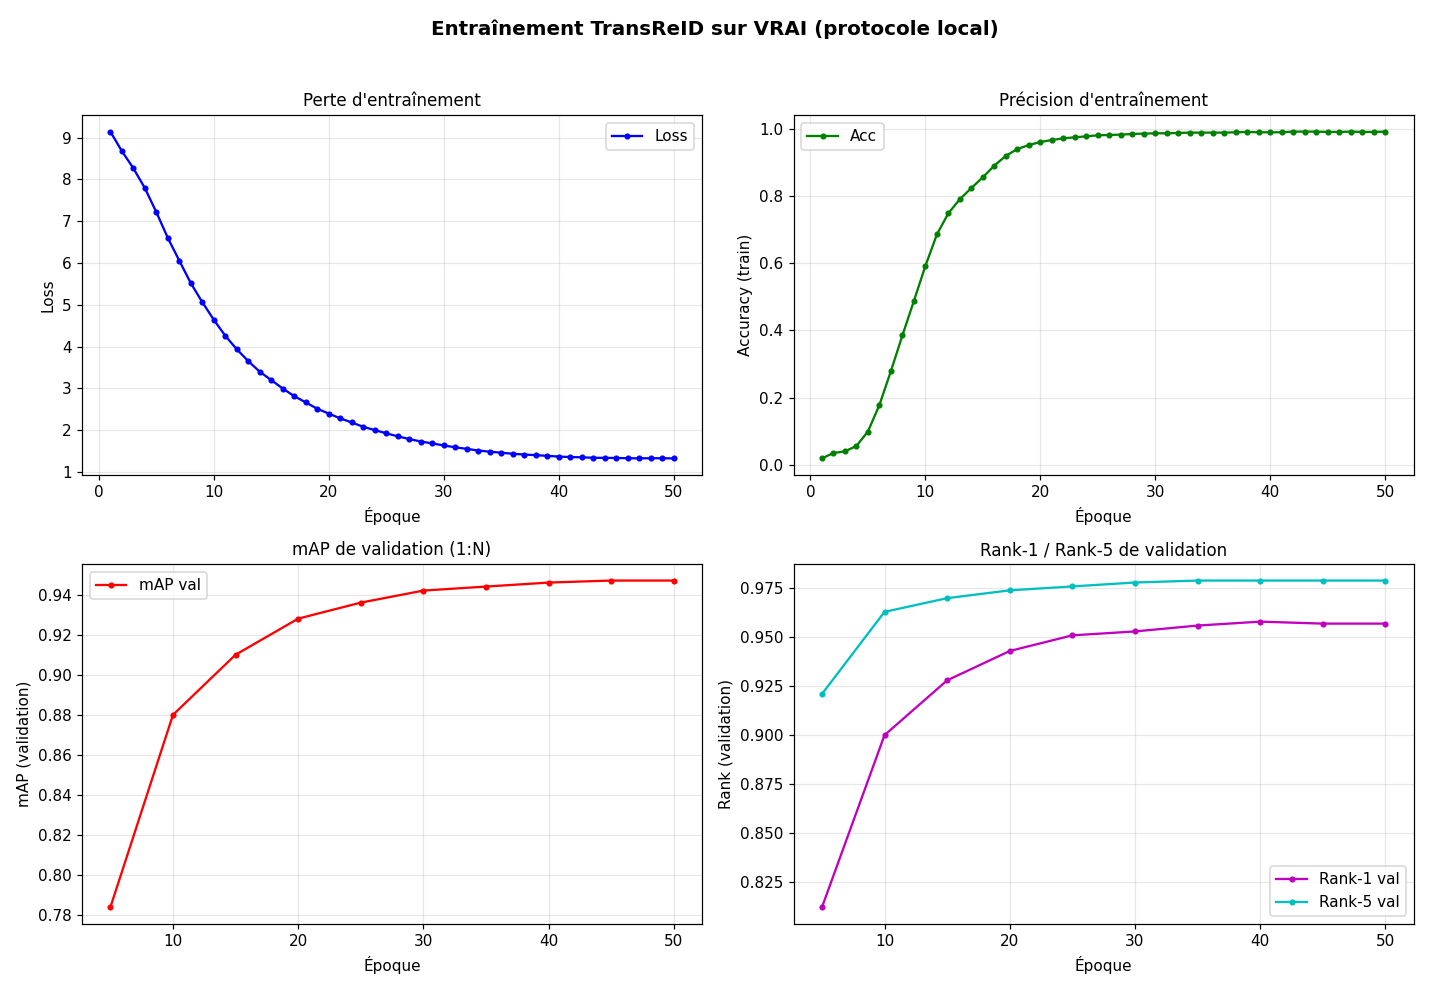

### cmc_curve.png


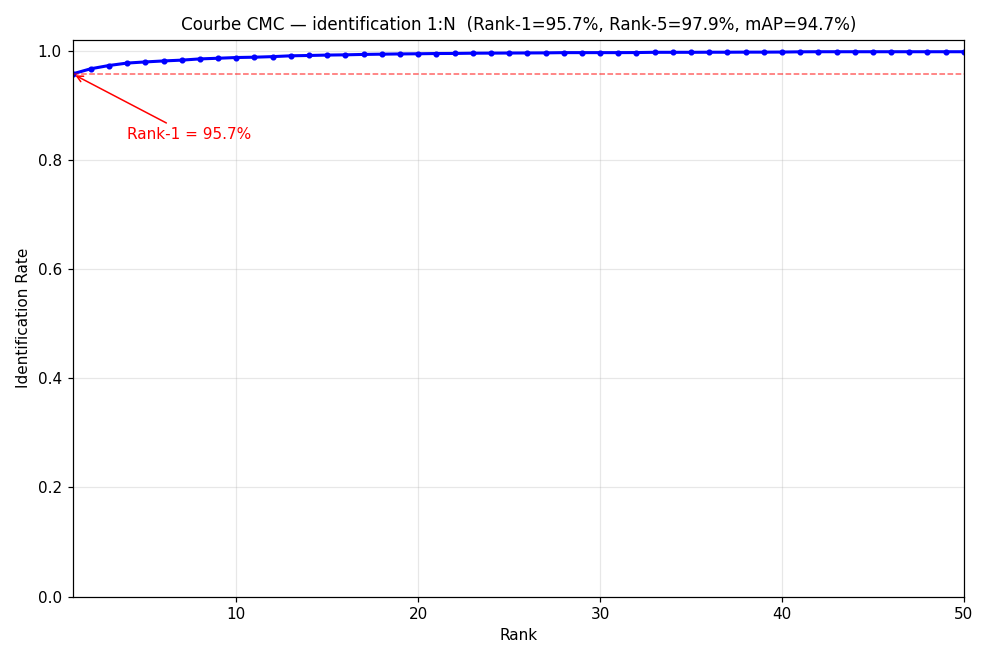

### roc_curve.png


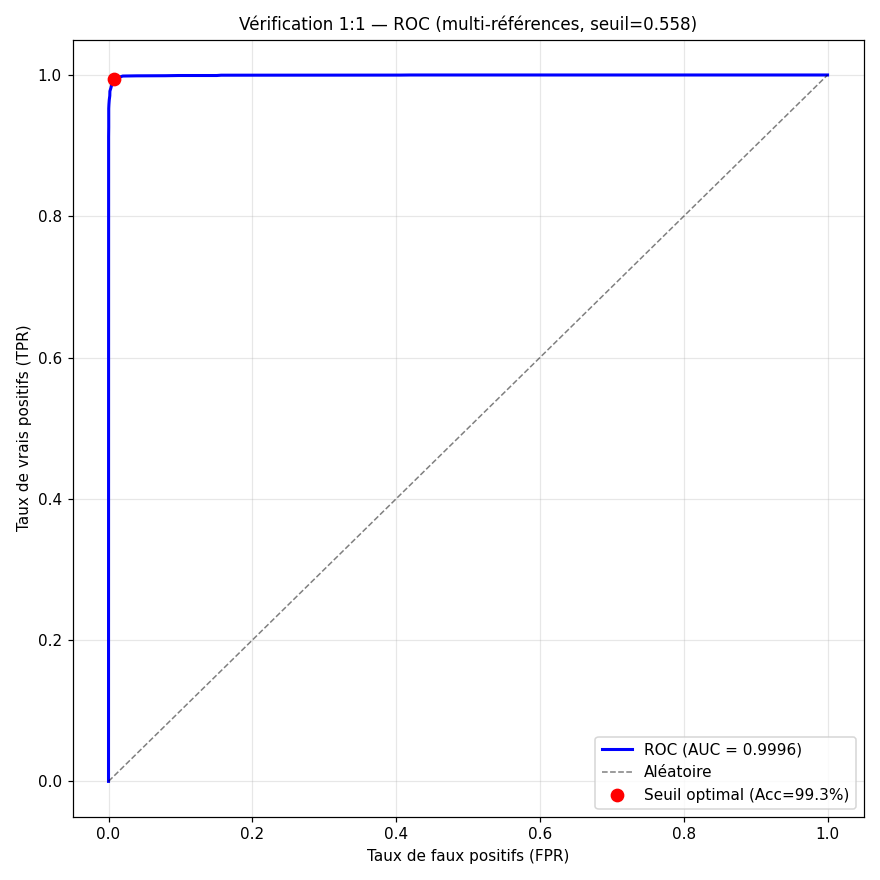

### latency_chart.png


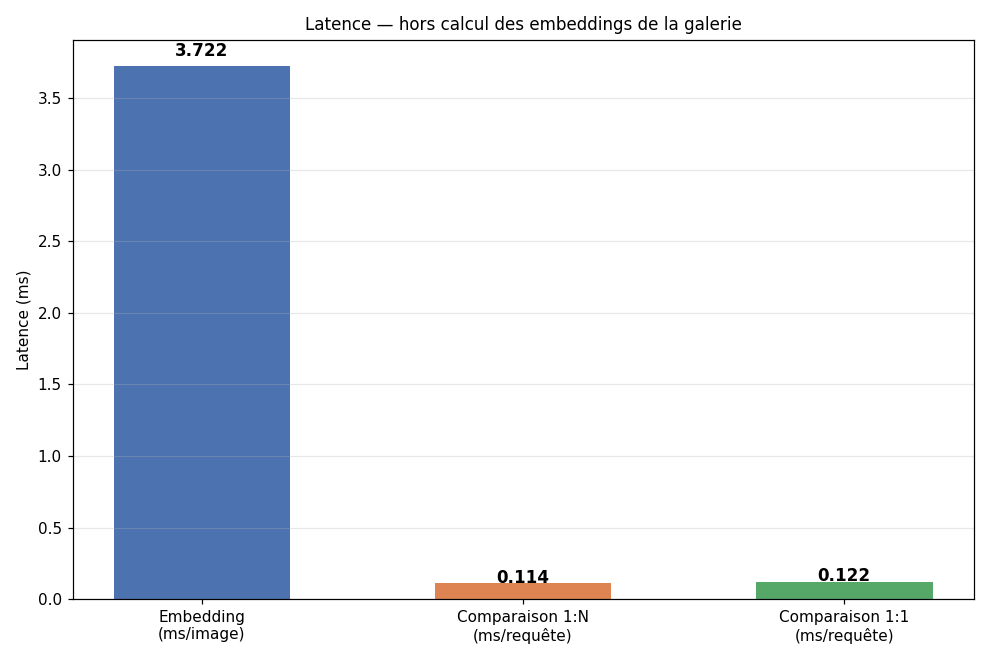

### retrieval_grid.png


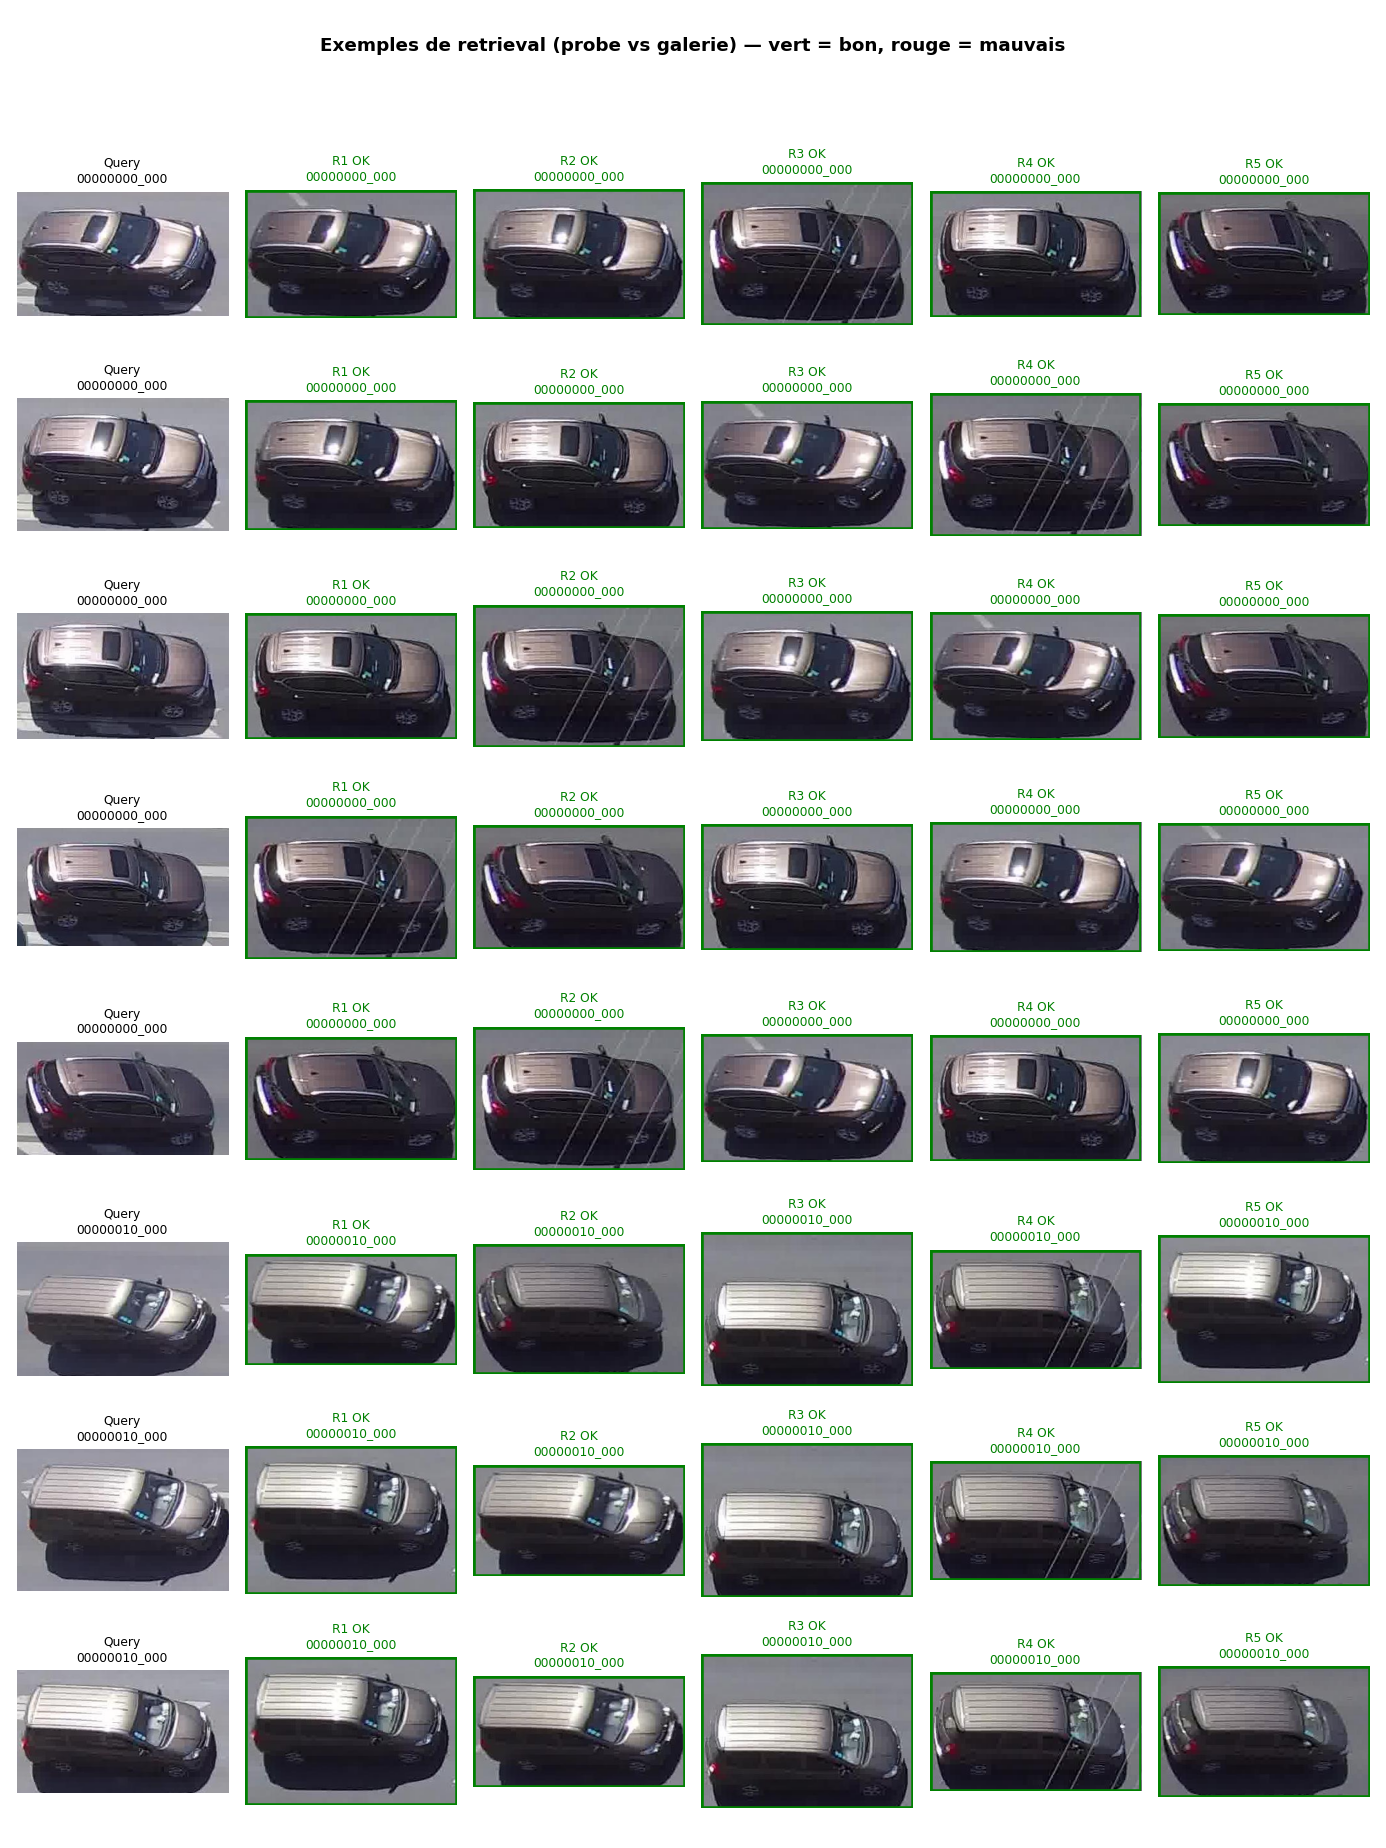

In [12]:
# ============ 9) AFFICHAGE DES GRAPHES ============
import os
from PIL import Image

RES = '/kaggle/working/results'
for f in ['training_curves.png', 'cmc_curve.png', 'roc_curve.png',
          'latency_chart.png', 'retrieval_grid.png']:
    p = os.path.join(RES, f)
    if os.path.isfile(p):
        print('###', f)
        display(Image.open(p))


In [ ]:
# ============ 10) MODÈLE FINAL + ZIP DES RÉSULTATS ============
import os, glob, shutil, zipfile

RES = '/kaggle/working/results'
os.makedirs(RES, exist_ok=True)

# modèle final : dernier checkpoint
ckpts = sorted(glob.glob('/kaggle/working/logs/vrai_deit_small_transreid/transformer_*.pth'))
assert ckpts, 'aucun checkpoint trouvé — entraînez d\'abord !'
final = os.path.join(RES, 'transreid_vrai_final.pth')
shutil.copy(ckpts[-1], final)
print(' Modèle final :', final)

# log d'entraînement
if os.path.isfile('/kaggle/working/train.log'):
    shutil.copy('/kaggle/working/train.log', os.path.join(RES, 'train.log'))

# zip de tous les résultats
out_zip = '/kaggle/working/transreid_vrai_results.zip'
with zipfile.ZipFile(out_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(os.listdir(RES)):
        zf.write(os.path.join(RES, f), f)
print(' Résultats zippés :', out_zip)
print()
print('Contenu de', RES, ':')
for f in sorted(os.listdir(RES)):
    print('   -', f)
print()
print(' Téléchargement : menu File > Download > transreid_vrai_results.zip')


🧠 Modèle final : /kaggle/working/results/transreid_vrai_final.pth
📦 Résultats zippés : /kaggle/working/transreid_vrai_results.zip

Contenu de /kaggle/working/results :
   - cmc_curve.png
   - latency_chart.png
   - rapport_evaluation_vrai.json
   - retrieval_grid.png
   - roc_curve.png
   - train.log
   - training_curves.png
   - transreid_vrai_final.pth

💾 Téléchargement : menu File > Download > transreid_vrai_results.zip


##  Fin du pipeline — récapitulatif des livrables

| Fichier | Rôle |
|---|---|
| `transreid_vrai_final.pth` | **Modèle final** TransReID entraîné sur VRAI (DeiT-Small + JPM) |
| `rapport_evaluation_vrai.json` | Métriques complètes (1:N, 1:1, latence, CMC, ROC) |
| `training_curves.png` | Loss/Acc d'entraînement + mAP/Rank-1 de validation |
| `cmc_curve.png` | Courbe CMC de l'identification 1:N |
| `roc_curve.png` | Courbe ROC de la vérification 1:1 (AUC) |
| `latency_chart.png` | Latence embedding / comparaison (hors galerie) |
| `retrieval_grid.png` | Exemples de retrieval (probe → top-5) |
| `train.log` | Journal d'entraînement complet |

**Remarque importante** : le protocole officiel VRAI (dev/test) n'est pas
évaluable localement (vérité terrain cachée côté serveur EvalAI). Ce notebook
utilise un protocole local rigoureux avec de vraies identités : split
déterministe (80 % IDs train / 20 % IDs éval disjoints), galerie = caméra
0001, requêtes = caméra 0002. Les métriques sont donc réelles et
reproductibles.
